# Прогнозирование срабатывания источников рисков

Бизнес-контекст:
В компании есть **бизнес-процессы**. Для каждого бизнес процесса определены **риски** - события, которые способны оказать негативное последствие и имеютпотенциал к реализации. У риков есть свои свойства: 
- уровеньущерба по видам и типам последствий;
-  зона присущего риска;
-  зона остататочного риска (т.е. после применения мер реагирования на риск)
-  консолидированная оценка воздействия.
  
По каждому риску могут происходить **риск-события**, т. е. ситуации, когда риск реализоавлся. У риск-событий есть свои свойства:
- event_name — номер риск-события
- event_date — дата происшествия риск-события;
- risk_event_source_name - номер причины риск-события;
- risk_event_source_group — группа источника риск-события (1 из 4);
- risk_event_reason_name — номер меры реагирования на риск-события;
- risk_event_reason_group — группа источника меры реагировавания (1 из 8);
- risk_event_reason_status — помогла ли мера реагирования
- consequence_name — номер последствия;
- consequence_type — тип последствия (деятельность, финансы, репутация, нет типа);
- consequence_kind — вид последствия (фактическое, возможное, удалось избежать, нет вида);
- loss_sum — фактические финансовые потери;
- reimburse_sum — фактическая сумма возмещения;
- consequence_influence_level — уровень воздействия последствия.

У каждого риск-события есть **источник** — одна или несколько причин, из-за которой реализовалось риск-события. Источники разделены по таксономии на 4 основные группы. Все источники принаддлежат одной из четырех групп. После реализации риск-события применяют **меры реагирования** — последовательность действий, которая направлена на минимзацию последствий. Меры разделены по таксономии на 8 групп. После реализации риск-события возникают "последствия", которые классифицируются по типу и виду, а также оцениваются по уровню воздействия.

**Задача**: предсказать вероятность срабатывания источника риск-события в следующем месяце.

In [2]:
#импорт библиотек

#стандартные настройки
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

## Описание исходного датасета

**Колонки бизнес-процесса и риска:**

- `bp_number` — номер бизнес-процесса
- `bp_name` — название бизнес-процесса
- `bp_is_active` — проверка, актуален ли бизнес-процесс
- `risk_name` — номер риска
- `risk_fin_loss` — уровень финансового ущерба
- `risk_business_rep` — уровень ущерба деловой репутации
- `risk_rating` — консолидированная оценка воздействия
- `present_risk_zone` — зона присущего риска
- `residual_risk_zone` — зона остаточного риска

**Колонки события и источника:**

- `event_name` — номер риск-события
- `event_date` — дата происшествия риск-события
- `risk_event_source_name` — ID источника риск-события
- `risk_event_source_group` — группа источника риск-события

**Колонки меры реагирования:**

- `risk_event_reason_name` — ID меры реагирования риск-события
- `risk_event_reason_group` — группа меры реагирования
- `risk_event_reason_status` — статус меры реагирования (сработала / не сработала)

**Колонки последствий:**

- `consequence_name` — номер последствия
- `consequence_type` — тип последствия (деятельность, финансы, репутация, нет типа)
- `consequence_kind` — вид последствия (фактическое, возможное, удалось избежать, нет вида)
- `loss_sum` — фактические финансовые потери
- `reimburse_sum` — фактическая сумма возмещения
- `consequence_influence_level` — уровень воздействия последствия

**Итого колонок:** 9 (бизнес-процесс и риск) + 4 (событие и источник) + 3 (меры реагирования) + 5 (последствия) = **21 колонка**.

In [4]:
#импорт исходного (обезличеннного) датасета 
df_raw = pd.read_csv('data_new_count.csv')
df.drop('count', axis=1, inplace=True)
print(df.shape)
df.tail(20)

(22482, 21)


,bp_number,bp_name,risk_name,risk_fin_loss,risk_business_rep,risk_rating,present_risk_zone,residual_risk_zone,event_name,event_date,risk_event_source_name,risk_event_source_group,risk_event_reason_name,risk_event_reason_group,risk_event_reason_status,consequence_name,consequence_type,consequence_kind,loss_sum,reimburse_sum,consequence_influence_level
22462,44,0044: название бизнес-процесса.,РC-0214,3,3,3,YELLOW,GREEN,РКС-2869,2025-09-26 16:08:06,РКП-4129,1.0,РСМ-7430,5.0,NOT_HELPED,РПС-4754,REPUTATION,POSSIBLE,NaN,NaN,1
22463,44,0044: название бизнес-процесса.,РC-0214,3,3,3,YELLOW,GREEN,РКС-2869,2025-09-26 16:08:06,РКП-4129,1.0,РСМ-7431,5.0,NOT_HELPED,РПС-4752,ACTIVITY,FACT,NaN,NaN,1
22464,44,0044: название бизнес-процесса.,РC-0214,3,3,3,YELLOW,GREEN,РКС-2869,2025-09-26 16:08:06,РКП-4129,1.0,РСМ-7431,5.0,NOT_HELPED,РПС-4753,ACTIVITY,FACT,NaN,NaN,1
22465,44,0044: название бизнес-процесса.,РC-0214,3,3,3,YELLOW,GREEN,РКС-2869,2025-09-26 16:08:06,РКП-4129,1.0,РСМ-7431,5.0,NOT_HELPED,РПС-4754,REPUTATION,POSSIBLE,NaN,NaN,1
22466,44,0044: название бизнес-процесса.,РC-0214,3,3,3,YELLOW,GREEN,РКС-2870,2025-07-10 16:12:09,РКП-4130,1.0,РСМ-7432,5.0,NOT_HELPED,РПС-4755,ACTIVITY,FACT,NaN,NaN,1
22467,44,0044: название бизнес-процесса.,РC-0214,3,3,3,YELLOW,GREEN,РКС-2870,2025-07-10 16:12:09,РКП-4130,1.0,РСМ-7432,5.0,NOT_HELPED,РПС-4756,REPUTATION,POSSIBLE,NaN,NaN,1
22468,44,0044: название бизнес-процесса.,РC-0214,3,3,3,YELLOW,GREEN,РКС-2871,2025-07-01 15:15:00,РКП-4131,1.0,РСМ-7433,5.0,NOT_HELPED,РПС-4757,ACTIVITY,FACT,NaN,NaN,1
22469,44,0044: название бизнес-процесса.,РC-0214,3,3,3,YELLOW,GREEN,РКС-2871,2025-07-01 15:15:00,РКП-4131,1.0,РСМ-7433,5.0,NOT_HELPED,РПС-4758,REPUTATION,POSSIBLE,NaN,NaN,1
22470,44,0044: название бизнес-процесса.,РC-0214,3,3,3,YELLOW,GREEN,РКС-2872,2025-02-13 17:53:23,РКП-4132,1.0,РСМ-7434,7.0,NOT_HELPED,РПС-4759,ACTIVITY,FACT,NaN,NaN,1
22471,44,0044: название бизнес-процесса.,РC-0214,3,3,3,YELLOW,GREEN,РКС-2872,2025-02-13 17:53:23,РКП-4132,1.0,РСМ-7434,7.0,HELPED,РПС-4759,ACTIVITY,FACT,NaN,NaN,1


In [5]:
#скрипт для получения базовой информации о датасете

def filter_risk_data(df, min_bp_events, min_risk_events):
    # Преобразование даты в datetime и создание месяца для группировки
    df['event_date'] = pd.to_datetime(df['event_date'])
    df['year_month'] = df['event_date'].dt.to_period('M')

    # Определение бизнес-процессов с количеством событий >= min_bp_events
    bp_counts = df['bp_number'].value_counts()
    top_bp = bp_counts[bp_counts >= min_bp_events].index.tolist()

    # Для каждого бизнес-процесса определяем риски с количеством событий >= min_risk_events
    filtered_data = []
    for bp in top_bp:
        bp_data = df[df['bp_number'] == bp]
        risk_counts = bp_data['risk_name'].value_counts()
        top_risks = risk_counts[risk_counts >= min_risk_events].index.tolist()
        if top_risks:  # добавляем данные, только если есть подходящие риски
            filtered_data.append(bp_data[bp_data['risk_name'].isin(top_risks)])

    df_filtered = pd.concat(filtered_data) if filtered_data else pd.DataFrame(columns=df.columns)

    print(f"Размер отфильтрованных данных: {df_filtered.shape}")

    # Анализ столбцов
    for col in df_filtered.columns:
        if df_filtered[col].nunique() < 20:
            print(f"Столбец: {col}")
            print(f"Категориальный: Да")
            print("Уникальные значения и их частоты:")
            print(df_filtered[col].value_counts())
            print("-" * 40)
        else:
            print(f"Столбец: {col}")
            print("Категориальный: Нет")
            print("-" * 40)

    return df_filtered

# Пример использования
df_filtered = filter_risk_data(df, min_bp_events=300, min_risk_events=50)

Размер отфильтрованных данных: (19358, 22)
Столбец: bp_number
Категориальный: Да
Уникальные значения и их частоты:
bp_number
38    6824
30    3871
14    1973
22    1640
7     1099
37     951
26     818
42     442
6      386
19     367
2      361
39     340
24     286
Name: count, dtype: int64
----------------------------------------
Столбец: bp_name
Категориальный: Да
Уникальные значения и их частоты:
bp_name
0038: название бизнес-процесса.    6824
0030: название бизнес-процесса.    3871
0014: название бизнес-процесса.    1973
0022: название бизнес-процесса.    1640
0007: название бизнес-процесса.    1099
0037: название бизнес-процесса.     951
0026: название бизнес-процесса.     818
0042: название бизнес-процесса.     442
0006: название бизнес-процесса.     386
0019: название бизнес-процесса.     367
0002: название бизнес-процесса.     361
0039: название бизнес-процесса.     340
0024: название бизнес-процесса.     286
Name: count, dtype: int64
----------------------------------------


In [6]:
print(df_filtered.shape)
df_filtered.head()

(19358, 22)


,bp_number,bp_name,risk_name,risk_fin_loss,risk_business_rep,risk_rating,present_risk_zone,residual_risk_zone,event_name,event_date,risk_event_source_name,risk_event_source_group,risk_event_reason_name,risk_event_reason_group,risk_event_reason_status,consequence_name,consequence_type,consequence_kind,loss_sum,reimburse_sum,consequence_influence_level,year_month
14308,38,0038: название бизнес-процесса.,РC-0164,1,3,3,YELLOW,YELLOW,РКС-1920,2026-01-28 00:00:00,РКП-2671,2.0,РСМ-5081,6.0,NOT_HELPED,РПС-3075,REPUTATION,POSSIBLE,NaN,NaN,2,2026-01
14309,38,0038: название бизнес-процесса.,РC-0164,1,3,3,YELLOW,YELLOW,РКС-1920,2026-01-28 00:00:00,РКП-2671,2.0,РСМ-5081,6.0,NOT_HELPED,РПС-3076,ACTIVITY,FACT,NaN,NaN,2,2026-01
14310,38,0038: название бизнес-процесса.,РC-0164,1,3,3,YELLOW,YELLOW,РКС-1920,2026-01-28 00:00:00,РКП-2671,2.0,РСМ-5082,4.0,NOT_HELPED,РПС-3075,REPUTATION,POSSIBLE,NaN,NaN,2,2026-01
14311,38,0038: название бизнес-процесса.,РC-0164,1,3,3,YELLOW,YELLOW,РКС-1920,2026-01-28 00:00:00,РКП-2671,2.0,РСМ-5082,4.0,NOT_HELPED,РПС-3076,ACTIVITY,FACT,NaN,NaN,2,2026-01
14312,38,0038: название бизнес-процесса.,РC-0164,1,3,3,YELLOW,YELLOW,РКС-1921,2025-11-10 18:23:24,РКП-2672,2.0,РСМ-5083,4.0,NOT_HELPED,РПС-3077,REPUTATION,POSSIBLE,NaN,NaN,2,2025-11


# Формирование датасета для МО

## Описание датасета для машинного обучения

**Колонки идентификации:**

- `bp_number` — номер бизнес-процесса
- `risk_name` — номер/название риска
- `year_month` — месяц данных (формат `ГГГГ-ММ`)

**Колонки энкодированных оценок риска:**

- `risk_rating_encoded` — закодированная консолидированная оценка воздействия риска (числовое значение)
- `risk_fin_loss_encoded` — закодированный уровень финансового ущерба риска
- `risk_business_rep_encoded` — закодированный уровень ущерба деловой репутации
- `present_risk_zone_encoded` — закодированная зона присущего риска (`0` – GREEN, `1` – YELLOW, `2` – RED)
- `residual_risk_zone_encoded` — закодированная зона остаточного риска (`0` – GREEN, `1` – YELLOW, `2` – RED)
- `consequence_type_encoded` — закодированный тип последствия (деятельность, финансы, репутация, нет типа)
- `consequence_influence_level_encoded` — закодированный уровень воздействия последствия

**Колонки событий и потерь за месяц:**

- `event_count` — общее количество риск-событий за месяц по данному риску
- `total_loss` — сумма фактических финансовых потерь за месяц
- `total_reimburse` — сумма возмещений за месяц
- `response_success` — количество сработавших мер реагирования на риск
- `response_failure` — количество несработавших мер реагирования на риск

**Колонки по источникам событий (количество и доля):**

- `source_1_count`, `source_2_count`, `source_3_count`, `source_4_count` — количество риск-событий за месяц по каждому источнику
- `source_1_ratio`, `source_2_ratio`, `source_3_ratio`, `source_4_ratio` — доля событий соответствующего источника от `event_count`

**Временные лаги и скользящие характеристики (по `event_count`):**

- `event_count_lag_1`, `event_count_lag_2`, `event_count_lag_3` — значение `event_count` за предыдущие 1, 2, 3 месяца соответственно
- `event_count_rolling_mean_3` — скользящее среднее `event_count` за предыдущие 3 месяца
- `event_count_rolling_std_3` — стандартное отклонение `event_count` за предыдущие 3 месяца
- `event_count_rolling_mean_6` — скользящее среднее `event_count` за предыдущие 6 месяцев
- `event_count_rolling_std_6` — стандартное отклонение `event_count` за предыдущие 6 месяцев
- `months_since_last_event` — количество месяцев, прошедших с последнего месяца, в котором было хотя бы одно событие (`0` – в текущем месяце есть события)
- `month_of_year` — номер месяца (от 1 до 12), извлечённый из `year_month`

**Лаги по источникам:**

- `source_1_count_lag_1`, `source_2_count_lag_1`, `source_3_count_lag_1`, `source_4_count_lag_1` — количество событий соответствующего источника в предыдущем месяце

**Целевые переменные (для прогнозирования на следующий месяц):**

- `target_source_1`, `target_source_2`, `target_source_3`, `target_source_4` — `1`, если в следующем месяце есть хотя бы одно событие данного источника, иначе `0`. Для последнего месяца в ряду значение отсутствует (`NaN`).


In [9]:
from sklearn.preprocessing import LabelEncoder

# 1. Фильтрация данных: только с 2020 года
df = df_filtered.copy()

df = df[df['event_date'] >= '2020-01-01'].copy()

# # 2. Фильтрация рисков: только риски с более чем 100 риск-событий (расскоментировать при необходимости)
# risk_event_counts = df.groupby(['bp_number', 'risk_name']).size()
# risks_with_many_events = risk_event_counts[risk_event_counts > 100].index.tolist()
# df = df[df.set_index(['bp_number', 'risk_name']).index.isin(risks_with_many_events)].copy()

# 3. Создание временной метки year_month
df['year_month'] = df['event_date'].dt.to_period('M').astype(str)

# 4. Кодирование категориальных переменных
zone_mapping = {'GREEN': 0, 'YELLOW': 1, 'RED': 2}
df['present_risk_zone_encoded'] = df['present_risk_zone'].map(zone_mapping).fillna(-1).astype(int)
df['residual_risk_zone_encoded'] = df['residual_risk_zone'].map(zone_mapping).fillna(-1).astype(int)

categorical_cols = [
    'risk_rating', 'risk_fin_loss', 'risk_business_rep',
    'consequence_type', 'consequence_influence_level'
]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# 5. Исправление: корректное преобразование risk_event_source_group в целые числа
df['risk_event_source_group'] = pd.to_numeric(df['risk_event_source_group'], errors='coerce').fillna(0).astype(int)

# 6. Агрегация по месяцам с дополнительными колонками для каждого источника
for source in [1, 2, 3, 4]:
    df[f'source_{source}_count'] = (df['risk_event_source_group'] == source).astype(int)

# 6.1 Индикаторы успешных / неуспешных мер реагирования
# Предполагаем, что успех обозначается 'HELPED', неуспех — 'NOT_HELPED'
# (при необходимости список значений можно расширить)
df['response_success'] = (df['risk_event_reason_status'].str.upper() == 'HELPED').astype(int)
df['response_failure'] = (df['risk_event_reason_status'].str.upper() == 'NOT_HELPED').astype(int)

# 6.2 Проверка сумм счётчиков (для отладки)
print("Проверка сумм счётчиков источников после создания:")
print(df[['source_1_count', 'source_2_count', 'source_3_count', 'source_4_count']].sum())
print("Проверка сумм успешных/неуспешных мер:")
print(df[['response_success', 'response_failure']].sum())

# Расширенный словарь агрегации
agg_dict = {
    'risk_rating_encoded': 'first',
    'risk_fin_loss_encoded': 'first',
    'risk_business_rep_encoded': 'first',
    'present_risk_zone_encoded': 'first',
    'residual_risk_zone_encoded': 'first',
    'consequence_type_encoded': 'first',
    'consequence_influence_level_encoded': 'first',
    'loss_sum': 'sum',
    'reimburse_sum': 'sum',
    'source_1_count': 'sum',
    'source_2_count': 'sum',
    'source_3_count': 'sum',
    'source_4_count': 'sum',
    'response_success': 'sum',
    'response_failure': 'sum'
}

monthly_data = df.groupby(['bp_number', 'risk_name', 'year_month']).agg(agg_dict).reset_index()

# 7. Добавление количества событий
event_counts = df.groupby(['bp_number', 'risk_name', 'year_month']).size().reset_index(name='event_count')
monthly_data = monthly_data.merge(event_counts, on=['bp_number', 'risk_name', 'year_month'])

# 8. Переименование колонок
monthly_data = monthly_data.rename(columns={
    'loss_sum': 'total_loss',
    'reimburse_sum': 'total_reimburse'
})

# 9. СОРТИРОВКА по дате
monthly_data['date_dt'] = pd.to_datetime(monthly_data['year_month'] + '-01')
monthly_data = monthly_data.sort_values(['bp_number', 'risk_name', 'date_dt']).reset_index(drop=True)

# 10. Создание полного набора дат для каждого риска и генерация временных признаков
date_range = pd.date_range('2020-01-01', '2025-11-01', freq='MS')
all_months = [d.strftime('%Y-%m') for d in date_range]

result_rows = []

# 10.1 Итерация по каждой комбинации бизнес-процесс–риск
for (bp_num, risk_name), group in monthly_data.groupby(['bp_number', 'risk_name']):
    # 10.1.1 Создание DataFrame с полным списком месяцев для данной комбинации
    full_dates = pd.DataFrame({
        'bp_number': bp_num,
        'risk_name': risk_name,
        'year_month': all_months,
        'date_dt': pd.to_datetime([m + '-01' for m in all_months])
    })
    
    # 10.1.2 Объединение с реальными данными (left join)
    group_full = pd.merge(full_dates, group,
                         on=['bp_number', 'risk_name', 'year_month', 'date_dt'],
                         how='left')
    
    # 10.1.3 Заполнение статических признаков (не меняются со временем)
    static_cols = ['risk_rating_encoded', 'risk_fin_loss_encoded', 'risk_business_rep_encoded',
                   'present_risk_zone_encoded', 'residual_risk_zone_encoded',
                   'consequence_type_encoded', 'consequence_influence_level_encoded']
    
    for col in static_cols:
        if group_full[col].isna().any() and not group_full[col].isna().all():
            group_full[col] = group_full[col].fillna(method='ffill').fillna(method='bfill')

    # 10.1.4 Заполнение динамических признаков нулями (отсутствие событий = 0)
    dynamic_cols = ['event_count', 'total_loss', 'total_reimburse',
                   'source_1_count', 'source_2_count', 'source_3_count', 'source_4_count',
                   'response_success', 'response_failure']
    
    for col in dynamic_cols:
        group_full[col] = group_full[col].fillna(0)
    
    # 10.1.5 Сортировка по дате и инициализация построчного расчёта признаков
    group_full = group_full.sort_values('date_dt').reset_index(drop=True)
    
    # 10.1.6 Цикл по месяцам для создания лаговых, скользящих и целевых признаков
    for i in range(len(group_full)):
        row = group_full.iloc[i].copy()
        
        # 10.1.7 Лаговые признаки количества событий (1, 2, 3 месяца назад)
        for lag in [1, 2, 3]:
            if i >= lag:
                row[f'event_count_lag_{lag}'] = group_full.iloc[i - lag]['event_count']
            else:
                row[f'event_count_lag_{lag}'] = np.nan
        
        # 10.1.8 Скользящие статистики за 3 и 6 месяцев (среднее и стандартное отклонение)
        if i > 0:
            prev_events = group_full.iloc[max(0, i-3):i]['event_count']
            row['event_count_rolling_mean_3'] = prev_events.mean() if len(prev_events) > 0 else np.nan
            row['event_count_rolling_std_3'] = prev_events.std() if len(prev_events) > 1 else np.nan
            
            prev_events_6 = group_full.iloc[max(0, i-6):i]['event_count']
            row['event_count_rolling_mean_6'] = prev_events_6.mean() if len(prev_events_6) > 0 else np.nan
            row['event_count_rolling_std_6'] = prev_events_6.std() if len(prev_events_6) > 1 else np.nan
            
            # 10.1.9 Лаг количества событий по каждому источнику за 1 месяц
            for source in ['1', '2', '3', '4']:
                if i >= 1:
                    row[f'source_{source}_count_lag_1'] = group_full.iloc[i-1][f'source_{source}_count']
                else:
                    row[f'source_{source}_count_lag_1'] = np.nan
        else:
            # Для самой первой записи скользящие и лаговые признаки не определены
            row['event_count_rolling_mean_3'] = np.nan
            row['event_count_rolling_std_3'] = np.nan
            row['event_count_rolling_mean_6'] = np.nan
            row['event_count_rolling_std_6'] = np.nan
            for source in ['1', '2', '3', '4']:
                row[f'source_{source}_count_lag_1'] = np.nan
        
        # 10.1.10 Количество месяцев с последнего события (0, если текущий месяц содержит событие или это начало ряда)
        if i > 0:
            months_since = 0
            for j in range(i-1, -1, -1):
                if group_full.iloc[j]['event_count'] > 0:
                    months_since = i - j
                    break
            row['months_since_last_event'] = months_since
        else:
            row['months_since_last_event'] = 0
        
        # 10.1.11 Циклический признак месяца года
        row['month_of_year'] = row['date_dt'].month
        
        # 10.1.12 Целевые переменные: будет ли событие конкретного источника в следующем месяце
        if i < len(group_full) - 1:
            for source in ['1', '2', '3', '4']:
                next_source_count = group_full.iloc[i+1][f'source_{source}_count']
                row[f'target_source_{source}'] = 1 if next_source_count > 0 else 0
        else:
            # Для последнего месяца целевые переменные отсутствуют (не можем знать будущее)
            for source in ['1', '2', '3', '4']:
                row[f'target_source_{source}'] = np.nan
        
        result_rows.append(row)

# 10.2 Сборка финального DataFrame из сформированных строк
final_dataset = pd.DataFrame(result_rows)

# 12. Создание дополнительных признаков для каждого источника (доля событий источника в общем количестве)
for source in ['1', '2', '3', '4']:
    final_dataset[f'source_{source}_ratio'] = final_dataset[f'source_{source}_count'] / final_dataset['event_count']
    final_dataset[f'source_{source}_ratio'] = final_dataset[f'source_{source}_ratio'].fillna(0)

# 13. Выбор финальных колонок (добавлены response_success и response_failure)
final_columns = [
    'bp_number', 'risk_name', 'year_month',
    'risk_rating_encoded', 'risk_fin_loss_encoded', 'risk_business_rep_encoded',
    'present_risk_zone_encoded', 'residual_risk_zone_encoded',
    'consequence_type_encoded', 'consequence_influence_level_encoded',
    'event_count', 'total_loss', 'total_reimburse',
    'source_1_count', 'source_2_count', 'source_3_count', 'source_4_count',
    'source_1_ratio', 'source_2_ratio', 'source_3_ratio', 'source_4_ratio',
    'event_count_lag_1', 'event_count_lag_2', 'event_count_lag_3',
    'event_count_rolling_mean_3', 'event_count_rolling_std_3',
    'event_count_rolling_mean_6', 'event_count_rolling_std_6',
    'months_since_last_event', 'month_of_year',
    'response_success', 'response_failure'
]

for source in ['1', '2', '3', '4']:
    final_columns.append(f'source_{source}_count_lag_1')

final_columns.extend(['target_source_1', 'target_source_2', 'target_source_3', 'target_source_4'])

final_dataset = final_dataset[final_columns].reset_index(drop=True)

# 14. Финальная сортировка по дате
final_dataset['date_dt'] = pd.to_datetime(final_dataset['year_month'] + '-01')
final_dataset = final_dataset.sort_values(['bp_number', 'risk_name', 'date_dt']).reset_index(drop=True)

# 15. Заполнение пропусков в признаках
# 15.1 Лаговые признаки событий (заполняем нулями, так как отсутствие данных = отсутствие событий)
for lag in [1, 2, 3]:
    final_dataset[f'event_count_lag_{lag}'] = final_dataset[f'event_count_lag_{lag}'].fillna(0)

for source in ['1', '2', '3', '4']:
    lag_col = f'source_{source}_count_lag_1'
    if lag_col in final_dataset.columns:
        final_dataset[lag_col] = final_dataset[lag_col].fillna(0)

# 15.2 Скользящие статистики: заполняем средним значением по всему набору
for col in ['event_count_rolling_mean_3', 'event_count_rolling_std_3',
            'event_count_rolling_mean_6', 'event_count_rolling_std_6']:
    mean_value = final_dataset[col].mean()
    final_dataset[col] = final_dataset[col].fillna(mean_value)

# 15.3 Финансовые показатели и новые счётчики заполняем нулями
final_dataset['total_loss'] = final_dataset['total_loss'].fillna(0)
final_dataset['total_reimburse'] = final_dataset['total_reimburse'].fillna(0)

final_dataset['response_success'] = final_dataset['response_success'].fillna(0)
final_dataset['response_failure'] = final_dataset['response_failure'].fillna(0)

for source in ['1', '2', '3', '4']:
    count_col = f'source_{source}_count'
    if count_col in final_dataset.columns:
        final_dataset[count_col] = final_dataset[count_col].fillna(0)

for source in ['1', '2', '3', '4']:
    ratio_col = f'source_{source}_ratio'
    final_dataset[ratio_col] = final_dataset[ratio_col].fillna(0)

# Удаляем вспомогательный столбец с датой, так как year_month уже присутствует
final_dataset = final_dataset.drop(columns=['date_dt'])

# Анализ датасета
print(f"\nФИНАЛЬНЫЙ ДАТАСЕТ:")
print(f"Размер: {final_dataset.shape}")
print(f"Количество признаков: {len(final_dataset.columns) - 4}")  # минус 4 целевых
print(f"Период данных: от {final_dataset['year_month'].min()} до {final_dataset['year_month'].max()}")

print("\n" + "="*60)
print("РАСПРЕДЕЛЕНИЕ КЛАССОВ В ЦЕЛЕВЫХ ПЕРЕМЕННЫХ (ВСЕ ДАННЫЕ)")
print("="*60)

target_cols = ['target_source_1', 'target_source_2', 'target_source_3', 'target_source_4']
for target in target_cols:
    valid_data = final_dataset[target].dropna()
    if len(valid_data) > 0:
        counts = valid_data.value_counts().sort_index()
        percentages = valid_data.value_counts(normalize=True).sort_index() * 100
        
        print(f"\n{target}:")
        print(f"  0 (нет событий): {counts.get(0, 0)} ({percentages.get(0, 0):.1f}%)")
        print(f"  1 (есть события): {counts.get(1, 0)} ({percentages.get(1, 0):.1f}%)")
        print(f"  Всего записей: {len(valid_data)}")
        print(f"  Пропусков (последний месяц): {final_dataset[target].isna().sum()}")
    else:
        print(f"\n{target}: Нет данных для анализа")

print("\n" + "="*60)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("="*60)
print(f"Записей: {len(final_dataset)}")
print(f"Уникальных бизнес-процессов: {final_dataset['bp_number'].nunique()}")
print(f"Уникальных рисков: {final_dataset['risk_name'].nunique()}")
print(f"Месяцев на каждый риск: {len(final_dataset) // final_dataset['risk_name'].nunique() if final_dataset['risk_name'].nunique() > 0 else 0}")
print(f"\nПример структуры данных:")
final_dataset.tail()

Проверка сумм счётчиков источников после создания:
source_1_count    12416
source_2_count     1040
source_3_count     4719
source_4_count      619
dtype: int64
Проверка сумм успешных/неуспешных мер:
response_success     4255
response_failure    14746
dtype: int64

ФИНАЛЬНЫЙ ДАТАСЕТ:
Размер: (4402, 40)
Количество признаков: 36
Период данных: от 2020-01 до 2025-11

РАСПРЕДЕЛЕНИЕ КЛАССОВ В ЦЕЛЕВЫХ ПЕРЕМЕННЫХ (ВСЕ ДАННЫЕ)

target_source_1:
  0 (нет событий): 3532 (81.4%)
  1 (есть события): 808 (18.6%)
  Всего записей: 4340
  Пропусков (последний месяц): 62

target_source_2:
  0 (нет событий): 4217 (97.2%)
  1 (есть события): 123 (2.8%)
  Всего записей: 4340
  Пропусков (последний месяц): 62

target_source_3:
  0 (нет событий): 3977 (91.6%)
  1 (есть события): 363 (8.4%)
  Всего записей: 4340
  Пропусков (последний месяц): 62

target_source_4:
  0 (нет событий): 4269 (98.4%)
  1 (есть события): 71 (1.6%)
  Всего записей: 4340
  Пропусков (последний месяц): 62

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Записей

,bp_number,risk_name,year_month,risk_rating_encoded,risk_fin_loss_encoded,risk_business_rep_encoded,present_risk_zone_encoded,residual_risk_zone_encoded,consequence_type_encoded,consequence_influence_level_encoded,event_count,total_loss,total_reimburse,source_1_count,source_2_count,source_3_count,source_4_count,source_1_ratio,source_2_ratio,source_3_ratio,source_4_ratio,event_count_lag_1,event_count_lag_2,event_count_lag_3,event_count_rolling_mean_3,event_count_rolling_std_3,event_count_rolling_mean_6,event_count_rolling_std_6,months_since_last_event,month_of_year,response_success,response_failure,source_1_count_lag_1,source_2_count_lag_1,source_3_count_lag_1,source_4_count_lag_1,target_source_1,target_source_2,target_source_3,target_source_4
4397,42,РC-0210,2025-07,2.0,2.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,5.333333,9.237604,6.000000,7.899367,2,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4398,42,РC-0210,2025-08,2.0,2.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,5.333333,9.237604,6.000000,7.899367,3,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4399,42,РC-0210,2025-09,2.0,2.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,5.333333,8.262364,4,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4400,42,РC-0210,2025-10,2.0,2.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,2.666667,6.531973,5,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4401,42,РC-0210,2025-11,2.0,2.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,2.666667,6.531973,6,11,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


# Обучение

## Обучение двухэтапной модели

- **Модели-кандидаты**: BalancedRandomForest, EasyEnsemble, HistGradientBoosting, VotingClassifier.
- **Подбор гиперпараметров**: Optuna (12–28 trials), TimeSeriesSplit (3 folds), целевая функция: AUC + Accuracy + F-мера.
- **Выбор порога**: перебор 0.10–0.92, взвешенный score (accuracy, F2/F1, G-mean, штрафы за ошибки, бонусы TP≥FN). После рефита сравниваются 5 стратегий (refit/original/cv_threshold/cv_upper/pre_refit).
- **Дисбаланс**: SMOTE (кроме source 2), Balanced-модели, исторические скоры для source 4.
- **Защита от утечки**: временной сплит, event_probability обучается только на train, исторические скоры только по train.



НАЧАЛО ОБУЧЕНИЯ ДВУХЭТАПНОЙ МОДЕЛИ
Размер полного датасета: (4402, 40)
Размер без исключенных месяцев: (4278, 40)
Исключены из train/test: ['2025-10', '2025-11']
Процент риск-событий: 21.3%
Признаков: 33
Тестовые месяцы: ['2025-07', '2025-08', '2025-09']
Месяцы для визуализации: ['2025-09', '2025-10']

Ожидаемые pos_rate:
  has_event: 0.3387
  target_source_1: 0.2849
  target_source_2: 0.0484
  target_source_3: 0.1398
  target_source_4: 0.0376

ЭТАП 1: ПРЕДСКАЗАНИЕ РИСК-СОБЫТИЙ

ОБУЧЕНИЕ: event
  Train: 3191 (pos=0.2165, n_pos=691)
  Val:   901 (pos=0.1865, n_pos=168)
  Target Acc: 0.82, min_P: 0.45, min_R: 0.48
  Weights: acc=0.25/f1=0.3/g=0.1
  fn_multiplier=1.5, fn_multiplier_bonus=0.1
  error_rate_weight=0.45
  fn_weight=0.08
  max_error_rate=0.15
  threshold_floor=0.76
  threshold_ceil=0.85
  max_fp_rate=0.1
  require_tp_gt_fn=True, tp_gt_fn_bonus=0.08
  cv_threshold_safety_margin=0.01
  cv_threshold_bonus=0.01
  SMOTE: ratio=0.15, max_mult=3
  force_ensemble_blend=True, weights=

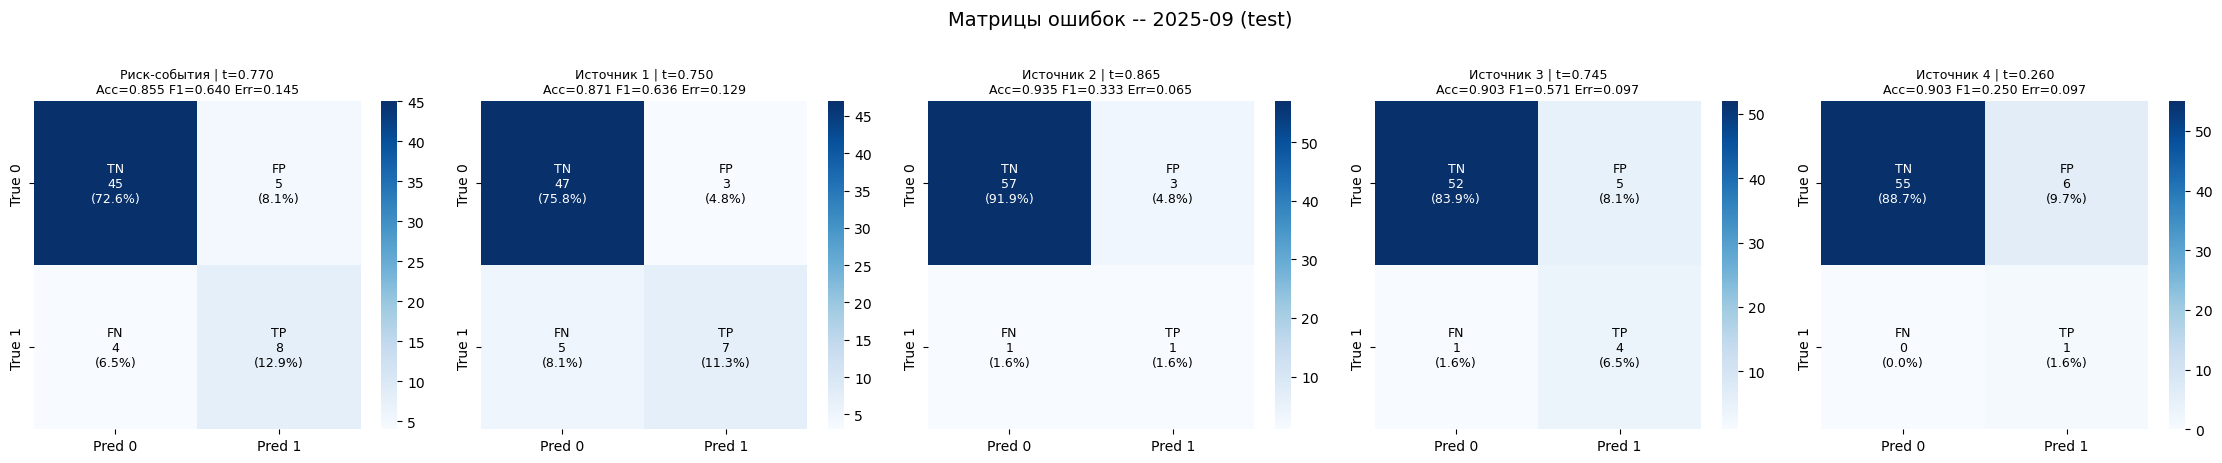

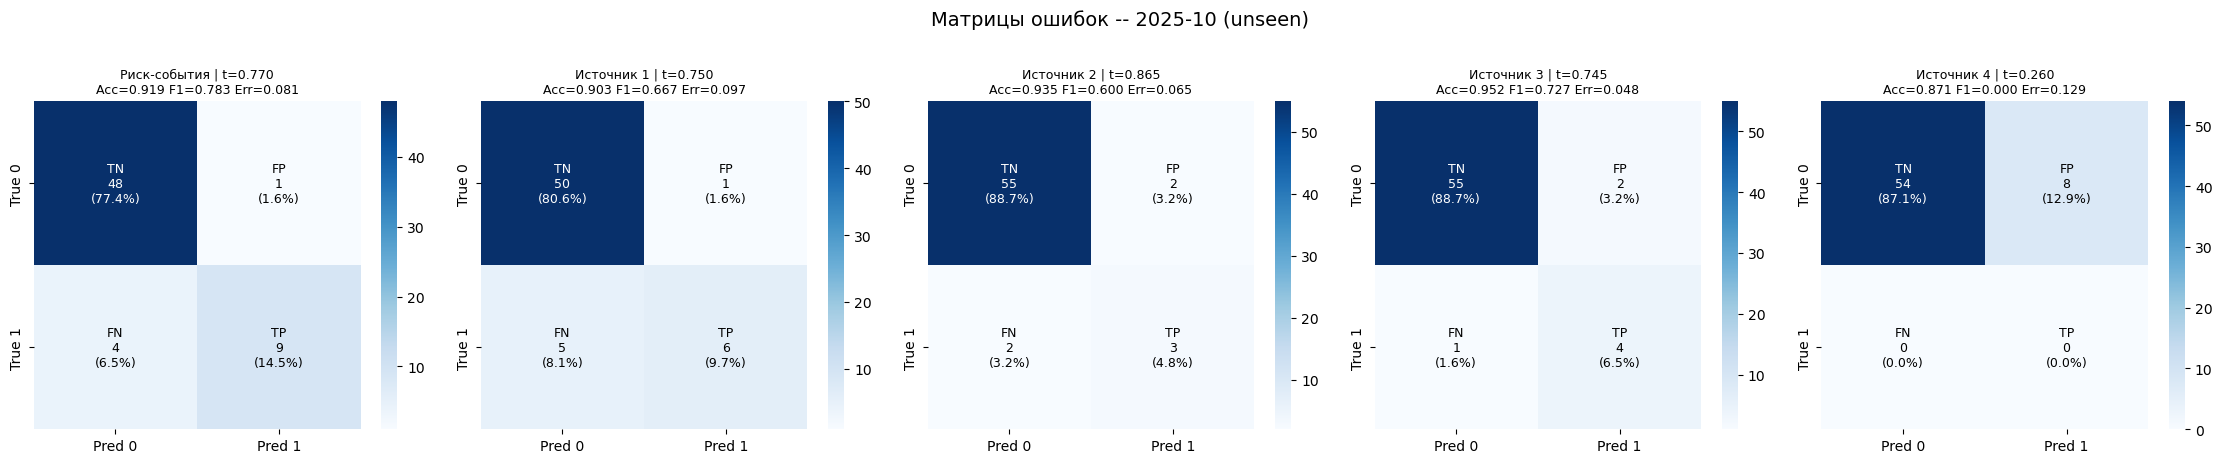



ОБУЧЕНИЕ ЗАВЕРШЕНО!


In [12]:
import numpy as np
import pandas as pd
import optuna
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    precision_score, recall_score, accuracy_score,
    fbeta_score, roc_auc_score, f1_score,
    confusion_matrix
)
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    VotingClassifier
)
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from imblearn.over_sampling import SMOTE
import joblib
import pickle

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


# Расчет метрик классификации (точность, полнота, F1, F2, AUC и др.)
def calculate_metrics(y_true, y_pred, y_pred_proba=None, src_num=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    n = tn + fp + fn + tp
    if n == 0:
        return {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0, 'f2': 0,
                'roc_auc': 0.5, 'g_mean': 0, 'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0,
                'fp_rate': 0, 'error_rate': 0, 'tp_gt_fn': False,
                'tp_ge_1_5_fn': False}
    acc = (tp + tn) / n
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1v = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    f2v = 5 * prec * rec / (4 * prec + rec) if (4 * prec + rec) > 0 else 0
    try:
        auc = roc_auc_score(y_true, y_pred_proba) if (
            y_pred_proba is not None and len(np.unique(y_true)) > 1) else 0.5
    except Exception:
        auc = 0.5

    if src_num == 4:
        tp_gt_fn = tp >= fn
    else:
        tp_gt_fn = tp > fn
    tp_ge_1_5_fn = tp >= 1.5 * fn

    return {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1v, 'f2': f2v, 'roc_auc': auc,
        'g_mean': np.sqrt(rec * spec),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
        'fp_rate': fp / n, 'error_rate': (fp + fn) / n,
        'tp_gt_fn': tp_gt_fn,
        'tp_ge_1_5_fn': tp_ge_1_5_fn
    }


# Подбор оптимального порога классификации по валидационным данным
def find_threshold(y_true, y_proba, target_accuracy=0.80,
                   min_precision=0.0, min_recall=0.0,
                   acc_weight=0.50, f1_weight=0.25, gmean_weight=0.25,
                   error_rate_weight=0.0,
                   force_acc_above_target=False,
                   max_fp_rate=None, max_error_rate=None,
                   use_f2=False, recall_bonus=0.0, fn_weight=0.0,
                   threshold_floor=None, threshold_ceil=None,
                   require_tp_gt_fn=False,
                   tp_gt_fn_bonus=0.0,
                   fn_multiplier=1.0,
                   fn_multiplier_bonus=0.0,
                   src_num=None):
    y_true = np.asarray(y_true, dtype=int)
    y_proba = np.asarray(y_proba)
    if np.sum(y_true) == 0:
        return threshold_floor or 0.5

    t_lo = threshold_floor or 0.10
    t_hi = threshold_ceil or 0.92
    thresholds = np.arange(t_lo, t_hi + 0.001, 0.005)
    good, fallback = [], []
    n_total = len(y_true)

    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        cm = confusion_matrix(y_true, pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        n = tn + fp + fn + tp
        if n == 0:
            continue
        acc = (tp + tn) / n
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        fp_rate = fp / n
        error_rate = (fp + fn) / n

        if max_fp_rate is not None and fp_rate > max_fp_rate:
            continue
        if max_error_rate is not None and error_rate > max_error_rate:
            continue

        f1v = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        f2v = 5 * prec * rec / (4 * prec + rec) if (4 * prec + rec) > 0 else 0
        gmean = np.sqrt(rec * spec)
        f_score = f2v if use_f2 else f1v

        score = acc * acc_weight + f_score * f1_weight + gmean * gmean_weight
        score += rec * recall_bonus
        score -= error_rate * error_rate_weight
        score -= (fn / n_total) * fn_weight

        if src_num == 4:
            tp_condition = tp >= fn
        else:
            tp_condition = tp > fn

        if tp_condition:
            score += tp_gt_fn_bonus

        if tp >= fn_multiplier * fn:
            score += fn_multiplier_bonus

        entry = {'t': t, 'score': score, 'acc': acc, 'prec': prec,
                 'rec': rec, 'f1': f1v, 'f2': f2v, 'gmean': gmean,
                 'fp': fp, 'fn': fn, 'tp': tp, 'tn': tn,
                 'fp_rate': fp_rate, 'error_rate': error_rate,
                 'tp_gt_fn': tp_condition,
                 'tp_ge_mult_fn': tp >= fn_multiplier * fn}
        fallback.append(entry)

        if acc >= target_accuracy and prec >= min_precision and rec >= min_recall:
            if require_tp_gt_fn and not tp_condition:
                continue
            good.append(entry)

    if good:
        return float(max(good, key=lambda x: x['score'])['t'])

    if require_tp_gt_fn and fallback:
        tp_ok = [c for c in fallback if c['tp_gt_fn']]
        if tp_ok:
            above_acc = [c for c in tp_ok if c['acc'] >= target_accuracy * 0.95]
            if above_acc:
                return float(max(above_acc, key=lambda x: x['score'])['t'])
            return float(max(tp_ok, key=lambda x: x['score'])['t'])

    if force_acc_above_target and fallback:
        above = [c for c in fallback if c['acc'] >= target_accuracy * 0.97]
        if above:
            return float(max(above, key=lambda x: x['score'])['t'])
        return float(max(fallback, key=lambda x: x['score'])['t'])

    if fallback:
        fallback.sort(key=lambda x: abs(x['acc'] - target_accuracy))
        top5 = fallback[:5]
        return float(max(top5, key=lambda x: x['score'])['t'])

    return threshold_floor or 0.5


# Вывод матрицы ошибок и основных метрик
def print_confusion_matrix(y_true, y_pred, title='', src_num=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    prec = tp / (tp + fp) if (tp + fp) else 0
    rec = tp / (tp + fn) if (tp + fn) else 0
    f1v = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
    f2v = 5 * prec * rec / (4 * prec + rec) if (4 * prec + rec) else 0
    acc = (tp + tn) / total if total > 0 else 0
    err = (fp + fn) / total if total > 0 else 0

    print(f"\nМатрица ошибок {title}:")
    print("=" * 70)
    print(f"{'':20s} Предсказано 0     Предсказано 1")
    print(f"Истинное 0       TN: {tn:4d} ({tn/total*100:5.1f}%)     "
          f"FP: {fp:4d} ({fp/total*100:5.1f}%)")
    print(f"Истинное 1       FN: {fn:4d} ({fn/total*100:5.1f}%)     "
          f"TP: {tp:4d} ({tp/total*100:5.1f}%)")
    print("=" * 70)
    print(f"  Acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  "
          f"F1={f1v:.4f}  F2={f2v:.4f}")
    print(f"  Err={err*100:.1f}%")
    print("=" * 70)


# Анализ чувствительности метрик к изменению порога
def analyze_threshold_sensitivity(y_true, y_proba, current_threshold, name="", src_num=None):
    y_true = np.asarray(y_true, dtype=int)
    print(f"\n  Анализ порогов для {name}:")
    print(f"  {'Порог':>7} {'Acc':>6} {'Prec':>6} {'Rec':>6} "
          f"{'F1':>6} {'F2':>6} {'TP':>4} {'FP':>4} {'FN':>4} {'TN':>4} "
          f"{'Err%':>5}")
    for t in np.arange(0.10, 0.95, 0.05):
        pred = (y_proba >= t).astype(int)
        cm = confusion_matrix(y_true, pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        total = tn + fp + fn + tp
        if total == 0:
            continue
        acc = (tp + tn) / total
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1v = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        f2v = 5 * prec * rec / (4 * prec + rec) if (4 * prec + rec) > 0 else 0
        err = (fp + fn) / total * 100
        marker = " <<<" if abs(t - current_threshold) < 0.03 else ""
        print(f"  {t:7.3f} {acc:6.3f} {prec:6.3f} {rec:6.3f} "
              f"{f1v:6.3f} {f2v:6.3f} {tp:4d} {fp:4d} {fn:4d} {tn:4d} "
              f"{err:5.1f}{marker}")


# Диагностика разбиения данных (доля целевого класса в train/val/test)
def diagnose_data_split(y_train, y_val, y_test=None, name=""):
    print(f"\n  Сплиты [{name}]:")
    print(f"    Train: n={len(y_train)}, pos={y_train.sum():.0f} ({y_train.mean():.4f})")
    print(f"    Val:   n={len(y_val)}, pos={y_val.sum():.0f} ({y_val.mean():.4f})")
    if y_test is not None and len(y_test) > 0:
        yt = np.asarray(y_test)
        print(f"    Test:  n={len(yt)}, pos={yt.sum():.0f} ({yt.mean():.4f})")
    if y_train.mean() > 0 and y_val.mean() > 0:
        ratio = max(y_train.mean() / y_val.mean(), y_val.mean() / y_train.mean())
        status = "ДРИФТ" if ratio > 2.5 else "OK"
        print(f"    Ratio: {ratio:.2f}x {status}")


# Оценка ожидаемой доли целевого класса на тесте по последним месяцам
def estimate_test_pos_rate(df, target_col, date_col, n_recent_months=6):
    months = sorted(df[date_col].unique())
    recent = months[-n_recent_months:] if len(months) >= n_recent_months else months
    recent_data = df[df[date_col].isin(recent)]
    return recent_data[target_col].mean() if len(recent_data) > 0 else 0.1


# Аугментация редкого класса с помощью SMOTE
def augment_rare(X_train, y_train, target_ratio=0.10, max_multiplier=5):
    n_pos = int(y_train.sum())
    n_neg = len(y_train) - n_pos
    if n_pos < 5:
        return X_train, y_train
    desired = min(int(n_neg * target_ratio), n_pos * max_multiplier)
    if desired <= n_pos:
        return X_train, y_train
    k = min(5, n_pos - 1)
    if k < 1:
        return X_train, y_train
    try:
        actual_ratio = desired / n_neg
        sampler = SMOTE(k_neighbors=k, random_state=42,
                        sampling_strategy=actual_ratio)
        X_res, y_res = sampler.fit_resample(X_train, y_train)
        print(f"    SMOTE: {n_pos} -> {int(y_res.sum())} pos")
        return X_res, y_res
    except Exception:
        return X_train, y_train


# Простая кросс-валидация по времени для AUC
def simple_cv_auc(model, X, y, n_splits=3):
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=1)
    aucs = []
    for tr_idx, vl_idx in tscv.split(X):
        X_tr, X_vl = X.iloc[tr_idx], X.iloc[vl_idx]
        y_tr, y_vl = y.iloc[tr_idx], y.iloc[vl_idx]
        if len(np.unique(y_tr)) < 2 or y_vl.sum() < 2:
            continue
        try:
            m = clone(model)
            m.fit(X_tr, y_tr)
            aucs.append(roc_auc_score(y_vl, m.predict_proba(X_vl)[:, 1]))
        except Exception:
            continue
    return (np.mean(aucs), np.std(aucs)) if aucs else (0.5, 0.0)


# Кросс-валидация для подбора порога
def cv_find_threshold(model, X, y, n_splits=4, **ft_kwargs):
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=1)
    thresholds = []
    for tr_idx, vl_idx in tscv.split(X):
        X_tr, X_vl = X.iloc[tr_idx], X.iloc[vl_idx]
        y_tr, y_vl = y.iloc[tr_idx], y.iloc[vl_idx]
        if len(np.unique(y_tr)) < 2 or y_vl.sum() < 2:
            continue
        try:
            m = clone(model)
            m.fit(X_tr, y_tr)
            proba = m.predict_proba(X_vl)[:, 1]
            t = find_threshold(y_vl, proba, **ft_kwargs)
            thresholds.append(t)
        except Exception:
            continue
    if thresholds:
        return np.median(thresholds), np.std(thresholds), len(thresholds), thresholds
    return 0.5, 0.0, 0, []


# Возвращает конфигурации моделей для разных уровней (event, source, source_rare)
def get_model_configs(level='event'):
    configs = {}
    if level == 'event':
        configs['BalancedRF'] = {
            'cls': BalancedRandomForestClassifier,
            'space': lambda trial: {
                'n_estimators': trial.suggest_int('n_estimators', 300, 600),
                'max_depth': trial.suggest_int('max_depth', 3, 6),
                'min_samples_split': trial.suggest_int('min_samples_split', 20, 60),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 40),
                'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                'ccp_alpha': trial.suggest_float('ccp_alpha', 0.005, 0.05),
                'random_state': 42, 'n_jobs': -1
            }
        }
        configs['EasyEnsemble'] = {
            'cls': 'EasyEnsemble',
            'space': lambda trial: {
                'n_estimators': trial.suggest_int('n_estimators', 10, 30),
                'sampling_strategy': 'auto',
                '_dt_max_depth': trial.suggest_int('_dt_max_depth', 2, 5),
                '_dt_min_samples_split': trial.suggest_int('_dt_min_samples_split', 10, 40),
                '_dt_min_samples_leaf': trial.suggest_int('_dt_min_samples_leaf', 5, 20),
            }
        }
        configs['HistGB'] = {
            'cls': HistGradientBoostingClassifier,
            'space': lambda trial: {
                'max_iter': trial.suggest_int('max_iter', 80, 200),
                'max_depth': trial.suggest_int('max_depth', 2, 4),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 30, 80),
                'l2_regularization': trial.suggest_float('l2_regularization', 5.0, 50, log=True),
                'max_bins': trial.suggest_int('max_bins', 32, 100),
                'class_weight': 'balanced',
                'random_state': 42, 'early_stopping': True,
                'validation_fraction': 0.15, 'n_iter_no_change': 10
            }
        }
    elif level == 'source':
        configs['BalancedRF'] = {
            'cls': BalancedRandomForestClassifier,
            'space': lambda trial: {
                'n_estimators': trial.suggest_int('n_estimators', 200, 500),
                'max_depth': trial.suggest_int('max_depth', 2, 5),
                'min_samples_split': trial.suggest_int('min_samples_split', 15, 50),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 8, 35),
                'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                'ccp_alpha': trial.suggest_float('ccp_alpha', 0.003, 0.05),
                'random_state': 42, 'n_jobs': -1
            }
        }
        configs['EasyEnsemble'] = {
            'cls': 'EasyEnsemble',
            'space': lambda trial: {
                'n_estimators': trial.suggest_int('n_estimators', 8, 22),
                'sampling_strategy': 'auto',
                '_dt_max_depth': trial.suggest_int('_dt_max_depth', 2, 5),
                '_dt_min_samples_split': trial.suggest_int('_dt_min_samples_split', 8, 30),
                '_dt_min_samples_leaf': trial.suggest_int('_dt_min_samples_leaf', 4, 15),
            }
        }
        configs['HistGB'] = {
            'cls': HistGradientBoostingClassifier,
            'space': lambda trial: {
                'max_iter': trial.suggest_int('max_iter', 50, 200),
                'max_depth': trial.suggest_int('max_depth', 2, 4),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 25, 70),
                'l2_regularization': trial.suggest_float('l2_regularization', 5.0, 50, log=True),
                'max_bins': trial.suggest_int('max_bins', 32, 80),
                'class_weight': 'balanced',
                'random_state': 42, 'early_stopping': True,
                'validation_fraction': 0.15, 'n_iter_no_change': 10
            }
        }
    elif level == 'source_rare':
        configs['BalancedRF'] = {
            'cls': BalancedRandomForestClassifier,
            'space': lambda trial: {
                'n_estimators': trial.suggest_int('n_estimators', 150, 400),
                'max_depth': trial.suggest_int('max_depth', 2, 5),
                'min_samples_split': trial.suggest_int('min_samples_split', 6, 25),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 15),
                'max_features': 'sqrt',
                'ccp_alpha': trial.suggest_float('ccp_alpha', 0.002, 0.04),
                'random_state': 42, 'n_jobs': -1
            }
        }
        configs['EasyEnsemble'] = {
            'cls': 'EasyEnsemble',
            'space': lambda trial: {
                'n_estimators': trial.suggest_int('n_estimators', 10, 30),
                'sampling_strategy': 'auto',
                '_dt_max_depth': trial.suggest_int('_dt_max_depth', 1, 4),
                '_dt_min_samples_split': trial.suggest_int('_dt_min_samples_split', 4, 15),
                '_dt_min_samples_leaf': trial.suggest_int('_dt_min_samples_leaf', 2, 8),
            }
        }
    return configs


# Сборка модели по конфигурации и параметрам (поддержка EasyEnsemble)
def build_model(config, params):
    if config['cls'] == 'EasyEnsemble':
        base_params = {k: v for k, v in params.items() if not k.startswith('_dt_')}
        tree_params = {k[4:]: v for k, v in params.items() if k.startswith('_dt_')}
        base_est = DecisionTreeClassifier(**tree_params, random_state=42)
        return EasyEnsembleClassifier(
            estimator=base_est, **base_params, random_state=42, n_jobs=-1)
    else:
        clean = {k: v for k, v in params.items() if not k.startswith('_')}
        return config['cls'](**clean)


# Класс для предсказания источника 4 с комбинированием ML и исторических скоров (без KNN)
class Src4ThresholdPredictor:
    def __init__(self, ranking_model, hist_scores, threshold=0.5,
                 alpha=0.3, cv_auc=0.5):
        self.ranking_model = ranking_model
        self.hist_scores = hist_scores
        self.threshold = threshold
        self.alpha = alpha
        self.cv_auc = cv_auc
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X):
        return self.ranking_model.predict_proba(X)

    def predict_combined(self, X, bp_values=None, risk_values=None):
        ml_proba = self.ranking_model.predict_proba(X)[:, 1]
        hist = np.zeros(len(X))
        if bp_values is not None and risk_values is not None:
            for i, (bp, risk) in enumerate(zip(bp_values, risk_values)):
                hist[i] = self.hist_scores.get((bp, risk), 0.0)

        hist_weight = 1.0 - self.alpha
        if np.sum(hist) > 0:
            combined = self.alpha * ml_proba + hist_weight * hist
        else:
            combined = ml_proba

        pred = (combined >= self.threshold).astype(int)
        return pred, combined


# Обучение модели для источника 4 с порогом и историческими данными (без KNN)
def train_source4_threshold(df, X_data, y_data, event_model, event_features,
                            train_end, test_start, test_end, date_col,
                            n_trials=15, alpha=0.25,
                            smote_ratio=0.12, smote_max_mult=6):
    print(f"\n{'='*80}")
    print(f"ОБУЧЕНИЕ: source_4 (threshold + historical)")
    print(f"{'='*80}")

    mask = df[date_col] < train_end
    X_full = X_data[mask].copy()
    y_full = y_data[mask].copy()
    valid = y_full.notna()
    X_full, y_full = X_full[valid], y_full[valid]

    src_cols = [c for c in ['target_source_1', 'target_source_2',
                            'target_source_3', 'target_source_4']
                if c in df.columns]
    has_ev = (df.loc[X_full.index, src_cols].sum(axis=1) > 0).astype(int)
    event_model_local = clone(event_model)
    feats_ev = [c for c in event_features if c in X_data.columns]
    event_model_local.fit(X_data.loc[X_full.index, feats_ev], has_ev)
    X_full['event_probability'] = event_model_local.predict_proba(
        X_data.loc[X_full.index, feats_ev])[:, 1]

    n_pos = int(y_full.sum())
    print(f"  Train: {len(X_full)} (pos={y_full.mean():.4f}, n_pos={n_pos})")
    print(f"  alpha={alpha}")

    train_df = df[mask].copy()
    hist_scores = {}
    if 'bp_number' in df.columns and 'risk_name' in df.columns:
        overall_rate = train_df['target_source_4'].mean() if 'target_source_4' in train_df.columns else 0.02
        grouped = train_df.groupby(['bp_number', 'risk_name'])
        for (bp, risk), group in grouped:
            if 'target_source_4' not in group.columns:
                continue
            n_total = len(group)
            n_pos_h = group['target_source_4'].sum()
            alpha_prior = 0.5
            beta_prior = alpha_prior * (1 / max(overall_rate, 0.005) - 1)
            score = (n_pos_h + alpha_prior) / (n_total + alpha_prior + beta_prior)
            hist_scores[(bp, risk)] = score

        if hist_scores:
            max_s = max(hist_scores.values())
            if max_s > 0:
                hist_scores = {k: v / max_s for k, v in hist_scores.items()}

        n_with = sum(1 for v in hist_scores.values() if v > 0.1)
        print(f"  Пар с hist_score > 0.1: {n_with}")

    X_aug, y_aug = augment_rare(X_full, y_full,
                                target_ratio=smote_ratio,
                                max_multiplier=smote_max_mult)

    configs = {
        'BalancedRF': {
            'cls': BalancedRandomForestClassifier,
            'space': lambda trial: {
                'n_estimators': trial.suggest_int('n_estimators', 200, 600),
                'max_depth': trial.suggest_int('max_depth', 2, 5),
                'min_samples_split': trial.suggest_int('min_samples_split', 3, 12),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
                'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                'ccp_alpha': trial.suggest_float('ccp_alpha', 0.001, 0.02),
                'random_state': 42, 'n_jobs': -1
            }
        },
        'EasyEnsemble': {
            'cls': 'EasyEnsemble',
            'space': lambda trial: {
                'n_estimators': trial.suggest_int('n_estimators', 15, 40),
                'sampling_strategy': 'auto',
                '_dt_max_depth': trial.suggest_int('_dt_max_depth', 2, 5),
                '_dt_min_samples_split': trial.suggest_int('_dt_min_samples_split', 2, 8),
                '_dt_min_samples_leaf': trial.suggest_int('_dt_min_samples_leaf', 1, 4),
            }
        },
        'HistGB': {
            'cls': HistGradientBoostingClassifier,
            'space': lambda trial: {
                'max_iter': trial.suggest_int('max_iter', 50, 150),
                'max_depth': trial.suggest_int('max_depth', 2, 4),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 40),
                'l2_regularization': trial.suggest_float('l2_regularization', 2.0, 30, log=True),
                'max_bins': trial.suggest_int('max_bins', 32, 80),
                'class_weight': 'balanced',
                'random_state': 42, 'early_stopping': True,
                'validation_fraction': 0.15, 'n_iter_no_change': 10
            }
        },
    }

    best_ranking = None
    best_cv_auc = 0
    best_name = ""

    for model_name, config in configs.items():
        print(f"\n  {model_name} (ranking)...")
        try:
            study = optuna.create_study(direction='maximize')

            def objective(trial, cfg=config):
                params = cfg['space'](trial)
                model = build_model(cfg, params)
                auc, _ = simple_cv_auc(model, X_full, y_full, n_splits=3)
                return auc

            study.optimize(objective, n_trials=n_trials,
                           show_progress_bar=False, catch=(Exception,))

            completed = [t for t in study.trials
                         if t.state == optuna.trial.TrialState.COMPLETE
                         and t.value is not None and t.value > 0]
            if not completed:
                continue

            best_params = max(completed, key=lambda t: t.value).params
            model = build_model(config, best_params)
            cv_auc, cv_std = simple_cv_auc(model, X_full, y_full, n_splits=3)
            print(f"    CV AUC: {cv_auc:.4f}+-{cv_std:.4f}")

            if cv_auc > best_cv_auc:
                best_cv_auc = cv_auc
                best_ranking = (config, best_params)
                best_name = model_name

        except Exception as e:
            print(f"    Error: {e}")

    if best_ranking is None:
        print("  Нет моделей для src4!")
        return None

    print(f"\n  Лучшая ranking: {best_name} (CV AUC={best_cv_auc:.4f})")

    final_ml_model = build_model(best_ranking[0], best_ranking[1])
    final_ml_model.fit(X_aug, y_aug)

    print(f"\n  Подбор threshold через CV...")
    tscv = TimeSeriesSplit(n_splits=4, gap=1)
    cv_results = []
    bp_full = df.loc[X_full.index, 'bp_number'].values if 'bp_number' in df.columns else None
    risk_full = df.loc[X_full.index, 'risk_name'].values if 'risk_name' in df.columns else None

    for fold_idx, (tr_idx, vl_idx) in enumerate(tscv.split(X_full)):
        X_tr, X_vl = X_full.iloc[tr_idx], X_full.iloc[vl_idx]
        y_tr, y_vl = y_full.iloc[tr_idx], y_full.iloc[vl_idx]
        if y_vl.sum() < 1:
            continue
        X_tr_aug, y_tr_aug = augment_rare(X_tr, y_tr,
                                           target_ratio=smote_ratio,
                                           max_multiplier=smote_max_mult)
        fold_model = build_model(best_ranking[0], best_ranking[1])
        fold_model.fit(X_tr_aug, y_tr_aug)
        ml_proba = fold_model.predict_proba(X_vl)[:, 1]

        hist_vl = np.zeros(len(X_vl))
        if bp_full is not None and risk_full is not None:
            bp_vl = bp_full[vl_idx]
            risk_vl = risk_full[vl_idx]
            for i, (bp, risk) in enumerate(zip(bp_vl, risk_vl)):
                hist_vl[i] = hist_scores.get((bp, risk), 0.0)

        hist_weight = 1.0 - alpha
        combined = alpha * ml_proba + hist_weight * hist_vl

        for t in np.arange(0.02, 0.50, 0.01):
            pred = (combined >= t).astype(int)
            cm = confusion_matrix(y_vl, pred, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            n = len(y_vl)
            err = (fp + fn) / n
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1v = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

            tp_ge_fn = tp >= fn
            tp_bonus = 0.25 if tp_ge_fn else 0
            err_penalty = max(0, err - 0.10) * 3.0
            target_met = 0.15 if (tp_ge_fn and err <= 0.15) else 0
            score = -err_penalty + rec * 0.30 + f1v * 0.20 + tp_bonus + target_met
            if err <= 0.08:
                score += 0.05

            cv_results.append({
                'fold': fold_idx, 't': t, 'err': err,
                'tp': tp, 'fp': fp, 'fn': fn,
                'prec': prec, 'rec': rec, 'f1': f1v,
                'score': score, 'tp_gt_fn': tp > fn,
                'tp_ge_fn': tp_ge_fn
            })

    if cv_results:
        cv_df = pd.DataFrame(cv_results)
        t_scores = cv_df.groupby('t').agg({
            'score': 'mean', 'err': 'mean',
            'tp': 'sum', 'fp': 'sum', 'fn': 'sum',
            'tp_gt_fn': 'mean', 'tp_ge_fn': 'mean'
        }).reset_index()

        valid_t = t_scores[(t_scores['tp'] >= t_scores['fn']) & (t_scores['err'] <= 0.15)]
        if len(valid_t) == 0:
            valid_t = t_scores[t_scores['tp'] >= t_scores['fn']]
        if len(valid_t) == 0:
            valid_t = t_scores[t_scores['err'] <= 0.15]
        if len(valid_t) == 0:
            valid_t = t_scores

        best_t_row = valid_t.loc[valid_t['score'].idxmax()]
        best_threshold = best_t_row['t']
        print(f"  CV лучший threshold: {best_threshold:.3f} "
              f"(err={best_t_row['err']*100:.1f}%, "
              f"TP={best_t_row['tp']:.0f} FP={best_t_row['fp']:.0f} "
              f"FN={best_t_row['fn']:.0f})")

        print(f"\n  Топ порогов по CV:")
        top_t = t_scores.nlargest(10, 'score')
        for _, row in top_t.iterrows():
            print(f"    t={row['t']:.3f}: err={row['err']*100:.1f}% "
                  f"TP={row['tp']:.0f} FP={row['fp']:.0f} FN={row['fn']:.0f} "
                  f"score={row['score']:.4f}")
    else:
        best_threshold = 0.15

    predictor = Src4ThresholdPredictor(
        ranking_model=final_ml_model,
        hist_scores=hist_scores,
        threshold=best_threshold,
        alpha=alpha,
        cv_auc=best_cv_auc
    )

    test_mask = (df[date_col] >= test_start)
    if test_end:
        test_mask &= (df[date_col] < test_end)
    X_test = X_data[test_mask].copy()
    y_test = y_data[test_mask].copy()
    valid_test = y_test.notna()
    X_test, y_test = X_test[valid_test], y_test[valid_test]

    X_test['event_probability'] = event_model_local.predict_proba(
        X_data.loc[X_test.index, feats_ev])[:, 1]

    bp_test = df.loc[X_test.index, 'bp_number'].values if 'bp_number' in df.columns else None
    risk_test = df.loc[X_test.index, 'risk_name'].values if 'risk_name' in df.columns else None

    test_true = y_test.values
    test_pred, test_scores = predictor.predict_combined(X_test, bp_test, risk_test)
    test_metrics = calculate_metrics(test_true, test_pred, test_scores, src_num=4)

    print(f"\n  Анализ threshold на тесте:")
    print(f"  {'t':>7} {'TP':>4} {'FP':>4} {'FN':>4} {'Err%':>6}")
    _, all_combined = predictor.predict_combined(X_test, bp_test, risk_test)
    for t in np.arange(0.02, 0.50, 0.02):
        pred_t = (all_combined >= t).astype(int)
        cm = confusion_matrix(test_true, pred_t, labels=[0, 1])
        tn_v, fp_v, fn_v, tp_v = cm.ravel()
        err = (fp_v + fn_v) / len(test_true) * 100
        marker = " <<<" if abs(t - best_threshold) < 0.015 else ""
        print(f"  {t:7.3f} {tp_v:4d} {fp_v:4d} {fn_v:4d} {err:6.1f}{marker}")

    print(f"\n  ТЕСТ: Acc={test_metrics['accuracy']:.4f} "
          f"F1={test_metrics['f1']:.4f} P={test_metrics['precision']:.4f} "
          f"R={test_metrics['recall']:.4f} "
          f"FP={test_metrics['fp']} FN={test_metrics['fn']} "
          f"Err={test_metrics['error_rate']*100:.1f}%")

    result = {
        'best_model_name': 'Src4Threshold',
        'best_model': predictor,
        'best_threshold': best_threshold,
        'best_metrics': {'accuracy': 0, 'precision': 0, 'recall': 0,
                         'f1': 0, 'f2': 0, 'error_rate': 0,
                         'fp': 0, 'fn': 0, 'tp': 0, 'tn': 0,
                         'tp_gt_fn': False, 'tp_ge_1_5_fn': False},
        'is_ensemble': False,
        'test_metrics': test_metrics,
        'test_true': test_true, 'test_pred': test_pred,
        'test_proba': test_scores,
        'feature_columns': list(X_full.columns),
        'cv_auc': best_cv_auc,
        'chosen_threshold_method': 'cv_combined',
        'event_model_full': event_model_local,
        'src_num': 4
    }

    print(f"\n  ИТОГО: Src4Threshold (t={best_threshold:.3f}, alpha={alpha})")
    print(f"    Ranking: {best_name}, CV AUC={best_cv_auc:.4f}")

    return result


# Основная функция обучения модели для одного таргета (event или source)
def train_model(df, X_data, y_data, prefix="",
                n_trials=12, level='event',
                add_event_prob=False,
                event_model_for_proba=None,
                event_features=None,
                train_end='2025-07', date_col='year_month',
                test_start=None, test_end=None,
                target_accuracy=0.80,
                min_precision=0.0, min_recall=0.0,
                acc_weight=0.40, f1_weight=0.30, gmean_weight=0.30,
                error_rate_weight=0.0,
                max_error_rate=None,
                fn_weight=0.0,
                use_augmentation=False,
                smote_ratio=0.10, smote_max_multiplier=5,
                val_split_ratio=0.78,
                force_acc_above_target=False,
                max_fp_rate=None,
                prefer_pre_refit=False,
                force_refit=False,
                force_cv_threshold=False,
                use_f2=False, recall_bonus=0.0,
                threshold_floor=None, threshold_ceil=None,
                cv_threshold_bonus=0.0,
                disable_voting=False,
                cv_threshold_safety_margin=0.0,
                cv_threshold_use_upper=False,
                cv_threshold_upper_pct=75,
                wf_threshold_floor=None,
                force_ensemble_blend=False,
                ensemble_blend_weights=None,
                require_tp_gt_fn=False,
                tp_gt_fn_bonus=0.0,
                fn_multiplier=1.0,
                fn_multiplier_bonus=0.0,
                max_error_rate_val_penalty=0.3,
                src_num=None):

    print(f"\n{'='*80}")
    print(f"ОБУЧЕНИЕ: {prefix}")
    print(f"{'='*80}")

    mask = df[date_col] < train_end
    X_full = X_data[mask].copy()
    y_full = y_data[mask].copy()
    valid = y_full.notna()
    X_full, y_full = X_full[valid], y_full[valid]

    n_pos_total = int(y_full.sum())
    if n_pos_total < 3:
        print(f"  [!] Слишком мало позитивов: {n_pos_total}. Пропуск.")
        return None

    split_idx = int(len(X_full) * val_split_ratio)
    X_train, X_val = X_full.iloc[:split_idx].copy(), X_full.iloc[split_idx:].copy()
    y_train, y_val = y_full.iloc[:split_idx], y_full.iloc[split_idx:]
    val_has_positives = (y_val.sum() >= 3)

    event_model_full_local = None
    if add_event_prob and event_model_for_proba is not None and event_features is not None:
        event_model_train = clone(event_model_for_proba)
        src_cols = [c for c in ['target_source_1', 'target_source_2',
                                'target_source_3', 'target_source_4']
                    if c in df.columns]
        has_ev_train = (df.loc[X_train.index, src_cols].sum(axis=1) > 0).astype(int)
        event_model_train.fit(X_data.loc[X_train.index, event_features], has_ev_train)
        X_train['event_probability'] = event_model_train.predict_proba(
            X_data.loc[X_train.index, event_features])[:, 1]
        X_val['event_probability'] = event_model_train.predict_proba(
            X_data.loc[X_val.index, event_features])[:, 1]
        print(f"  + event_probability (без утечки)")

    ft_kwargs = dict(
        target_accuracy=target_accuracy,
        min_precision=min_precision, min_recall=min_recall,
        acc_weight=acc_weight, f1_weight=f1_weight, gmean_weight=gmean_weight,
        error_rate_weight=error_rate_weight,
        force_acc_above_target=force_acc_above_target,
        max_fp_rate=max_fp_rate, max_error_rate=max_error_rate,
        use_f2=use_f2, recall_bonus=recall_bonus,
        fn_weight=fn_weight,
        threshold_floor=threshold_floor, threshold_ceil=threshold_ceil,
        require_tp_gt_fn=require_tp_gt_fn,
        tp_gt_fn_bonus=tp_gt_fn_bonus,
        fn_multiplier=fn_multiplier,
        fn_multiplier_bonus=fn_multiplier_bonus,
        src_num=src_num
    )

    print(f"  Train: {len(X_train)} (pos={y_train.mean():.4f}, n_pos={int(y_train.sum())})")
    print(f"  Val:   {len(X_val)} (pos={y_val.mean():.4f}, n_pos={int(y_val.sum())})")
    print(f"  Target Acc: {target_accuracy:.2f}, min_P: {min_precision}, min_R: {min_recall}")
    print(f"  Weights: acc={acc_weight}/f1={f1_weight}/g={gmean_weight}")
    print(f"  fn_multiplier={fn_multiplier}, fn_multiplier_bonus={fn_multiplier_bonus}")
    if error_rate_weight > 0: print(f"  error_rate_weight={error_rate_weight}")
    if fn_weight > 0: print(f"  fn_weight={fn_weight}")
    if max_error_rate: print(f"  max_error_rate={max_error_rate}")
    if threshold_floor: print(f"  threshold_floor={threshold_floor}")
    if threshold_ceil: print(f"  threshold_ceil={threshold_ceil}")
    if force_acc_above_target: print(f"  force_acc_above_target=True")
    if max_fp_rate is not None: print(f"  max_fp_rate={max_fp_rate}")
    if require_tp_gt_fn: print(f"  require_tp_gt_fn=True, tp_gt_fn_bonus={tp_gt_fn_bonus}")
    if force_refit: print(f"  force_refit=True")
    if force_cv_threshold: print(f"  force_cv_threshold=True")
    if cv_threshold_safety_margin > 0: print(f"  cv_threshold_safety_margin={cv_threshold_safety_margin}")
    if disable_voting: print(f"  disable_voting=True")
    if cv_threshold_bonus > 0: print(f"  cv_threshold_bonus={cv_threshold_bonus}")
    if use_augmentation: print(f"  SMOTE: ratio={smote_ratio}, max_mult={smote_max_multiplier}")
    if force_ensemble_blend: print(f"  force_ensemble_blend=True, weights={ensemble_blend_weights}")

    X_train_aug, y_train_aug = X_train, y_train
    if use_augmentation and y_train.sum() >= 5:
        X_train_aug, y_train_aug = augment_rare(
            X_train, y_train, target_ratio=smote_ratio,
            max_multiplier=smote_max_multiplier)

    configs = get_model_configs(level)
    all_results = {}

    for model_name, config in configs.items():
        print(f"\n  {model_name}: {n_trials} trials...")
        try:
            study = optuna.create_study(direction='maximize')

            def objective(trial, cfg=config, _val_ok=val_has_positives):
                try:
                    params = cfg['space'](trial)
                except Exception:
                    raise optuna.TrialPruned()
                model = build_model(cfg, params)
                model.fit(X_train_aug, y_train_aug)

                if _val_ok:
                    proba = model.predict_proba(X_val)[:, 1]
                    try:
                        auc = roc_auc_score(y_val, proba)
                    except Exception:
                        auc = 0.5
                    t = find_threshold(y_val, proba, **ft_kwargs)
                    pred = (proba >= t).astype(int)
                    acc = accuracy_score(y_val, pred)
                    f1v = f1_score(y_val, pred, zero_division=0)
                    f2v = fbeta_score(y_val, pred, beta=2, zero_division=0)
                    f_metric = f2v if use_f2 else f1v
                    rec = recall_score(y_val, pred, zero_division=0)
                    err = 1 - acc
                    cm = confusion_matrix(y_val, pred, labels=[0, 1])
                    _, fp_o, fn_o, tp_o = cm.ravel()
                    if src_num == 4:
                        tp_condition = tp_o >= fn_o
                    else:
                        tp_condition = tp_o > fn_o
                    tp_bonus = 0.05 if tp_condition else 0
                    mult_bonus = 0.05 if tp_o >= fn_multiplier * fn_o else 0
                    return (auc * 0.30 + f_metric * 0.25 + acc * 0.25
                            + rec * recall_bonus - err * error_rate_weight * 0.20
                            + tp_bonus + mult_bonus)
                else:
                    cv_auc_q, _ = simple_cv_auc(model, X_train, y_train, n_splits=3)
                    return cv_auc_q

            study.optimize(objective, n_trials=n_trials,
                           show_progress_bar=False, catch=(Exception,))

            completed = [t for t in study.trials
                         if t.state == optuna.trial.TrialState.COMPLETE
                         and t.value is not None
                         and not np.isnan(t.value) and t.value > 0]
            if not completed:
                print(f"    Нет успешных trials"); continue

            best_params = max(completed, key=lambda t: t.value).params
            best_model = build_model(config, best_params)
            best_model.fit(X_train_aug, y_train_aug)

            cv_auc, cv_std = simple_cv_auc(best_model, X_train, y_train, n_splits=3)

            if val_has_positives:
                proba = best_model.predict_proba(X_val)[:, 1]
                threshold = find_threshold(y_val, proba, **ft_kwargs)
                pred = (proba >= threshold).astype(int)
                val_metrics = calculate_metrics(y_val, pred, proba, src_num=src_num)
            else:
                proba = best_model.predict_proba(X_val)[:, 1]
                cv_t, _, _, _ = cv_find_threshold(
                    best_model, X_train, y_train, n_splits=4, **ft_kwargs)
                threshold = cv_t
                pred = (proba >= threshold).astype(int)
                val_metrics = calculate_metrics(y_val, pred, proba, src_num=src_num)

            val_auc = val_metrics.get('roc_auc', 0.5)
            overfit_pen = max(0, (val_auc - cv_auc) - 0.05) * 0.3 if cv_auc > 0 else 0

            f_metric = val_metrics['f2'] if use_f2 else val_metrics['f1']
            err = val_metrics['error_rate']
            if val_has_positives:
                val_score = (val_metrics['accuracy'] * 0.25 +
                             f_metric * 0.25 +
                             val_metrics['g_mean'] * 0.10 +
                             val_metrics['recall'] * recall_bonus +
                             cv_auc * 0.30 - overfit_pen
                             - err * error_rate_weight * 0.10)
                if val_metrics['tp_gt_fn']:
                    val_score += tp_gt_fn_bonus * 0.5
                if val_metrics.get('tp_ge_1_5_fn', False):
                    val_score += fn_multiplier_bonus * 0.5
                if val_metrics['accuracy'] < target_accuracy:
                    gap = target_accuracy - val_metrics['accuracy']
                    val_score *= (1.0 - gap * 1.0)
                if max_error_rate is not None and err > max_error_rate:
                    val_score -= max_error_rate_val_penalty * (err - max_error_rate)
            else:
                val_score = cv_auc

            all_results[model_name] = {
                'model': best_model, 'params': best_params,
                'threshold': threshold,
                'val_metrics': val_metrics, 'val_score': val_score,
                'cv_auc': cv_auc, 'cv_std': cv_std,
                'val_proba': proba
            }

            print(f"    CV AUC: {cv_auc:.4f}+-{cv_std:.4f}")
            print(f"    Val: Acc={val_metrics['accuracy']:.4f} "
                  f"F1={val_metrics['f1']:.4f} "
                  f"P={val_metrics['precision']:.4f} "
                  f"R={val_metrics['recall']:.4f} "
                  f"FP={val_metrics['fp']} FN={val_metrics['fn']} "
                  f"Err={err*100:.1f}% "
                  f"t={threshold:.4f}")

        except Exception as e:
            print(f"    Ошибка: {e}")
            import traceback; traceback.print_exc()

    if not all_results:
        print("  Нет моделей!")
        return None

    sorted_models = sorted(all_results.items(),
                           key=lambda x: x[1]['val_score'], reverse=True)

    if force_ensemble_blend and len(sorted_models) >= 2 and val_has_positives:
        print(f"\n  Force Ensemble Blend...")
        blend_weights = ensemble_blend_weights or {}
        try:
            estimators, weights = [], []
            for name, info in sorted_models[:3]:
                w = blend_weights.get(name, 1.0)
                estimators.append((name, clone(info['model'])))
                weights.append(w)
            w_sum = sum(weights)
            weights = [w / w_sum for w in weights]
            voting = VotingClassifier(estimators=estimators, voting='soft',
                                      weights=weights, n_jobs=-1)
            voting.fit(X_train_aug, y_train_aug)
            v_proba = voting.predict_proba(X_val)[:, 1]
            v_t = find_threshold(y_val, v_proba, **ft_kwargs)
            v_pred = (v_proba >= v_t).astype(int)
            v_m = calculate_metrics(y_val, v_pred, v_proba, src_num=src_num)
            avg_cv = np.mean([i['cv_auc'] for _, i in sorted_models[:3]])
            f_metric = v_m['f2'] if use_f2 else v_m['f1']
            v_score = (v_m['accuracy'] * 0.25 + f_metric * 0.25 +
                       v_m['g_mean'] * 0.10 + v_m['recall'] * recall_bonus +
                       avg_cv * 0.30
                       - v_m['error_rate'] * error_rate_weight * 0.10)
            if v_m['tp_gt_fn']:
                v_score += tp_gt_fn_bonus * 0.5
            if v_m.get('tp_ge_1_5_fn', False):
                v_score += fn_multiplier_bonus * 0.5
            if v_m['accuracy'] < target_accuracy:
                v_score *= (1.0 - (target_accuracy - v_m['accuracy']) * 1.0)
            if max_error_rate is not None and v_m['error_rate'] > max_error_rate:
                v_score -= max_error_rate_val_penalty * (v_m['error_rate'] - max_error_rate)
            v_score += 0.02
            all_results['ForceBlend'] = {
                'model': voting, 'params': {'blend_weights': blend_weights},
                'threshold': v_t,
                'val_metrics': v_m, 'val_score': v_score,
                'cv_auc': avg_cv, 'cv_std': 0.0, 'val_proba': v_proba,
                'is_ensemble': True
            }
            print(f"    ForceBlend: Acc={v_m['accuracy']:.4f} "
                  f"F1={v_m['f1']:.4f} P={v_m['precision']:.4f} "
                  f"R={v_m['recall']:.4f} "
                  f"FP={v_m['fp']} FN={v_m['fn']} "
                  f"Err={v_m['error_rate']*100:.1f}% t={v_t:.4f}")
        except Exception as e:
            print(f"    ForceBlend failed: {e}")

    if len(sorted_models) >= 2 and val_has_positives and not disable_voting:
        print(f"\n  Voting ансамбль...")
        top = sorted_models[:3]
        try:
            weights = np.array([i['val_score'] for _, i in top])
            weights = np.maximum(weights, 0.01)
            weights = weights / weights.sum()
            estimators = [(f"m{j}", clone(i['model'])) for j, (_, i) in enumerate(top)]
            voting = VotingClassifier(estimators=estimators, voting='soft',
                                      weights=weights.tolist(), n_jobs=-1)
            voting.fit(X_train_aug, y_train_aug)
            v_proba = voting.predict_proba(X_val)[:, 1]
            v_t = find_threshold(y_val, v_proba, **ft_kwargs)
            v_pred = (v_proba >= v_t).astype(int)
            v_m = calculate_metrics(y_val, v_pred, v_proba, src_num=src_num)
            avg_cv = np.mean([i['cv_auc'] for _, i in top])
            f_metric = v_m['f2'] if use_f2 else v_m['f1']
            v_score = (v_m['accuracy'] * 0.25 + f_metric * 0.25 +
                       v_m['g_mean'] * 0.10 + v_m['recall'] * recall_bonus +
                       avg_cv * 0.30
                       - v_m['error_rate'] * error_rate_weight * 0.10)
            if v_m['tp_gt_fn']:
                v_score += tp_gt_fn_bonus * 0.5
            if v_m.get('tp_ge_1_5_fn', False):
                v_score += fn_multiplier_bonus * 0.5
            if v_m['accuracy'] < target_accuracy:
                v_score *= (1.0 - (target_accuracy - v_m['accuracy']) * 1.0)
            if max_error_rate is not None and v_m['error_rate'] > max_error_rate:
                v_score -= max_error_rate_val_penalty * (v_m['error_rate'] - max_error_rate)
            all_results['Ensemble_voting'] = {
                'model': voting, 'params': {}, 'threshold': v_t,
                'val_metrics': v_m, 'val_score': v_score,
                'cv_auc': avg_cv, 'cv_std': 0.0, 'val_proba': v_proba,
                'is_ensemble': True
            }
            print(f"    Voting: Acc={v_m['accuracy']:.4f} F1={v_m['f1']:.4f} "
                  f"P={v_m['precision']:.4f} R={v_m['recall']:.4f} "
                  f"FP={v_m['fp']} FN={v_m['fn']} "
                  f"Err={v_m['error_rate']*100:.1f}% t={v_t:.4f}")
        except Exception as e:
            print(f"    Voting failed: {e}")

    print(f"\n  Кандидаты:")
    for name, info in sorted(all_results.items(),
                              key=lambda x: x[1]['val_score'], reverse=True):
        m = info['val_metrics']
        print(f"    {name:30} Acc={m['accuracy']:.4f} "
              f"F1={m['f1']:.4f} P={m['precision']:.4f} R={m['recall']:.4f} "
              f"FP={m['fp']} FN={m['fn']} Err={m['error_rate']*100:.1f}% "
              f"CV={info['cv_auc']:.4f} "
              f"Score={info['val_score']:.4f}")

    best_name = max(all_results, key=lambda k: all_results[k]['val_score'])
    best_info = all_results[best_name]
    print(f"\n  >>> Выбрана: {best_name} (Score={best_info['val_score']:.4f})")

    if best_name not in ('Ensemble_voting', 'ForceBlend') and val_has_positives:
        print_confusion_matrix(
            y_val.values,
            (best_info['val_proba'] >= best_info['threshold']).astype(int),
            best_name, src_num=src_num)

    print(f"\n  Refit на всех данных ({len(X_full)})...")

    X_full_final = X_full.copy()
    if add_event_prob and event_model_for_proba is not None and event_features is not None:
        event_model_full_local = clone(event_model_for_proba)
        src_cols = [c for c in ['target_source_1', 'target_source_2',
                                'target_source_3', 'target_source_4']
                    if c in df.columns]
        has_ev_full = (df.loc[X_full.index, src_cols].sum(axis=1) > 0).astype(int)
        event_model_full_local.fit(
            X_data.loc[X_full.index, event_features], has_ev_full)
        X_full_final['event_probability'] = event_model_full_local.predict_proba(
            X_data.loc[X_full.index, event_features])[:, 1]

    if use_augmentation and y_full.sum() >= 5:
        X_full_aug, y_full_aug = augment_rare(
            X_full_final, y_full, target_ratio=smote_ratio,
            max_multiplier=smote_max_multiplier)
    else:
        X_full_aug, y_full_aug = X_full_final, y_full

    final_model = clone(best_info['model'])
    final_model.fit(X_full_aug, y_full_aug)

    pre_refit_model = best_info['model']
    pre_refit_proba = pre_refit_model.predict_proba(X_val)[:, 1]
    t_pre_refit = best_info['threshold']

    if val_has_positives:
        X_val_for_refit = X_val.copy()
        if add_event_prob and event_model_full_local is not None and event_features is not None:
            X_val_for_refit['event_probability'] = event_model_full_local.predict_proba(
                X_data.loc[X_val.index, event_features])[:, 1]

        refit_proba = final_model.predict_proba(X_val_for_refit)[:, 1]
        t_refit = find_threshold(y_val, refit_proba, **ft_kwargs)

        cv_t, cv_t_std, cv_t_n, cv_t_all = cv_find_threshold(
            final_model, X_full_final, y_full, n_splits=4, **ft_kwargs)
        print(f"  CV threshold: median={cv_t:.4f} (std={cv_t_std:.4f}, n={cv_t_n})")
        if cv_t_all:
            print(f"  CV thresholds: {[f'{t:.4f}' for t in cv_t_all]}")

        cv_t_with_margin = min(cv_t + cv_threshold_safety_margin,
                               threshold_ceil or 0.95)

        if cv_threshold_use_upper and cv_t_all and len(cv_t_all) >= 3:
            cv_t_upper = np.percentile(cv_t_all, cv_threshold_upper_pct)
            cv_t_upper_with_margin = min(cv_t_upper + cv_threshold_safety_margin,
                                         threshold_ceil or 0.95)
        else:
            cv_t_upper_with_margin = cv_t_with_margin

        if wf_threshold_floor is not None:
            cv_t_with_margin = max(cv_t_with_margin, wf_threshold_floor)
            cv_t_upper_with_margin = max(cv_t_upper_with_margin, wf_threshold_floor)

        candidates_t = [
            ('refit', t_refit, final_model, refit_proba),
            ('original', t_pre_refit, final_model, refit_proba),
            ('pre_refit', t_pre_refit, pre_refit_model, pre_refit_proba),
        ]
        if cv_t_n >= 2:
            candidates_t.append(('cv_threshold', cv_t_with_margin,
                                 final_model, refit_proba))
        if cv_threshold_use_upper and cv_t_all and len(cv_t_all) >= 3:
            candidates_t.append(('cv_upper', cv_t_upper_with_margin,
                                 final_model, refit_proba))

        print(f"\n  Сравнение порогов после refit:")
        best_t_entry = None
        best_t_score = -999

        for t_name, t_val, t_model, t_proba in candidates_t:
            pred = (t_proba >= t_val).astype(int)
            m = calculate_metrics(y_val, pred, t_proba, src_num=src_num)

            f_metric = m['f2'] if use_f2 else m['f1']
            sc = (m['accuracy'] * acc_weight + f_metric * f1_weight +
                  m['g_mean'] * gmean_weight + m['recall'] * recall_bonus
                  - m['error_rate'] * error_rate_weight
                  - (m['fn'] / len(y_val)) * fn_weight)

            if m['tp_gt_fn']:
                sc += tp_gt_fn_bonus
            if m.get('tp_ge_1_5_fn', False):
                sc += fn_multiplier_bonus

            if m['accuracy'] < target_accuracy:
                sc *= (1.0 - (target_accuracy - m['accuracy']) * 1.0)
            if max_error_rate is not None and m['error_rate'] > max_error_rate:
                sc -= max_error_rate_val_penalty * (m['error_rate'] - max_error_rate)

            if prefer_pre_refit and 'pre' in t_name: sc += 0.005
            if force_refit and t_name == 'refit': sc += 0.015
            if force_cv_threshold and t_name == 'cv_threshold': sc += 0.025
            if force_cv_threshold and t_name == 'cv_upper': sc += 0.030
            if t_name in ('cv_threshold', 'cv_upper'): sc += cv_threshold_bonus

            print(f"    {t_name:16}: t={t_val:.4f} Acc={m['accuracy']:.4f} "
                  f"F1={m['f1']:.4f} P={m['precision']:.4f} R={m['recall']:.4f} "
                  f"FP={m['fp']:3d} FN={m['fn']:3d} "
                  f"Err={m['error_rate']*100:.1f}% Score={sc:.4f}")

            if sc > best_t_score:
                best_t_score = sc
                best_t_entry = (t_name, t_val, t_model, t_proba)

        chosen_name, final_threshold, chosen_model, _ = best_t_entry
    else:
        cv_t, cv_t_std, cv_t_n, cv_t_all = cv_find_threshold(
            final_model, X_full_final, y_full, n_splits=4, **ft_kwargs)
        if cv_t_n >= 2:
            base_t = cv_t
            if cv_threshold_use_upper and cv_t_all and len(cv_t_all) >= 3:
                base_t = np.percentile(cv_t_all, cv_threshold_upper_pct)
                chosen_name = 'cv_upper'
            else:
                chosen_name = 'cv_threshold'
            final_threshold = min(base_t + cv_threshold_safety_margin,
                                  threshold_ceil or 0.95)
            if wf_threshold_floor and final_threshold < wf_threshold_floor:
                final_threshold = wf_threshold_floor
        else:
            final_threshold = t_pre_refit
            chosen_name = 'original'
        chosen_model = final_model

    print(f"  >>> Порог: {final_threshold:.4f} ({chosen_name})")

    if 'pre' in chosen_name:
        final_model = pre_refit_model
        print(f"  Используем pre-refit модель")
    else:
        final_model = chosen_model if chosen_model is not None else final_model

    test_metrics = None
    test_true = test_pred = test_proba_arr = None
    if test_start:
        test_mask_t = (df[date_col] >= test_start)
        if test_end:
            test_mask_t &= (df[date_col] < test_end)
        X_test = X_data[test_mask_t].copy()
        y_test = y_data[test_mask_t].copy()
        valid_test = y_test.notna()
        X_test, y_test = X_test[valid_test], y_test[valid_test]

        if add_event_prob and event_model_full_local is not None and event_features is not None:
            X_test['event_probability'] = event_model_full_local.predict_proba(
                X_data.loc[X_test.index, event_features])[:, 1]

        if len(X_test) > 0:
            feats = [c for c in list(X_train.columns) if c in X_test.columns]
            test_proba_arr = final_model.predict_proba(X_test[feats])[:, 1]
            test_pred = (test_proba_arr >= final_threshold).astype(int)
            test_true = y_test.values

            if y_test.sum() > 0:
                test_metrics = calculate_metrics(test_true, test_pred, test_proba_arr, src_num=src_num)
                print(f"\n  ТЕСТ: Acc={test_metrics['accuracy']:.4f} "
                      f"F1={test_metrics['f1']:.4f} P={test_metrics['precision']:.4f} "
                      f"R={test_metrics['recall']:.4f} "
                      f"FP={test_metrics['fp']} FN={test_metrics['fn']} "
                      f"Err={test_metrics['error_rate']*100:.1f}%")
                analyze_threshold_sensitivity(
                    test_true, test_proba_arr, final_threshold, prefix, src_num=src_num)
            else:
                test_metrics = calculate_metrics(test_true, test_pred, test_proba_arr, src_num=src_num)
                print(f"\n  ТЕСТ (0 pos): Acc={test_metrics['accuracy']:.4f} "
                      f"FP={test_metrics['fp']}")

    result = {
        'best_model_name': best_name,
        'best_model': final_model,
        'best_threshold': final_threshold,
        'best_metrics': best_info['val_metrics'],
        'is_ensemble': best_info.get('is_ensemble', False),
        'test_metrics': test_metrics,
        'test_true': test_true, 'test_pred': test_pred,
        'test_proba': test_proba_arr,
        'feature_columns': list(X_train.columns),
        'cv_auc': best_info['cv_auc'],
        'chosen_threshold_method': chosen_name,
        'src_num': src_num
    }
    if event_model_full_local is not None:
        result['event_model_full'] = event_model_full_local

    print(f"\n  ИТОГО: {result['best_model_name']} "
          f"(метод порога: {chosen_name})")
    print(f"    Val: Acc={best_info['val_metrics']['accuracy']:.4f} "
          f"F1={best_info['val_metrics']['f1']:.4f} "
          f"Err={best_info['val_metrics']['error_rate']*100:.1f}%")
    print(f"    CV AUC={best_info['cv_auc']:.4f}, Порог={final_threshold:.4f}")

    return result


# Построение матриц ошибок по месяцам для всех моделей
def plot_monthly_results(df, event_result, source_results,
                         X_all, event_features,
                         plot_months, date_col='year_month',
                         test_months_set=None):
    target_cols_map = {1: 'target_source_1', 2: 'target_source_2',
                       3: 'target_source_3', 4: 'target_source_4'}

    for month in plot_months:
        month_mask = df[date_col] == month
        if month_mask.sum() == 0:
            print(f"  Нет данных для {month}"); continue
        X_month = X_all[month_mask].copy()
        month_idx = df[month_mask].index
        month_results = {}
        month_type = ("test" if test_months_set and month in test_months_set
                      else "unseen")

        if event_result:
            y_ev = df.loc[month_idx, 'has_event'].values.astype(int)
            feats_ev = [c for c in event_features if c in X_month.columns]
            proba_ev = event_result['best_model'].predict_proba(X_month[feats_ev])[:, 1]
            pred_ev = (proba_ev >= event_result['best_threshold']).astype(int)
            month_results['Риск-события'] = {
                'y_true': y_ev, 'y_pred': pred_ev,
                'threshold': event_result['best_threshold'], 'src_num': None}

        for src_num in sorted(source_results.keys()):
            r = source_results[src_num]
            col = target_cols_map[src_num]
            if col not in df.columns:
                continue
            y_s = df.loc[month_idx, col].values.astype(int)
            X_src = X_month.copy()

            if 'event_model_full' in r:
                feats_ev = [c for c in event_features if c in X_month.columns]
                X_src['event_probability'] = r['event_model_full'].predict_proba(
                    X_month[feats_ev])[:, 1]

            feats = [c for c in r.get('feature_columns', []) if c in X_src.columns]
            if not feats:
                feats = list(X_src.columns)

            model = r['best_model']
            if isinstance(model, Src4ThresholdPredictor):
                bp_vals = (df.loc[month_idx, 'bp_number'].values
                           if 'bp_number' in df.columns else None)
                risk_vals = (df.loc[month_idx, 'risk_name'].values
                             if 'risk_name' in df.columns else None)
                pred_s, _ = model.predict_combined(X_src[feats], bp_vals, risk_vals)
            else:
                proba_s = model.predict_proba(X_src[feats])[:, 1]
                pred_s = (proba_s >= r['best_threshold']).astype(int)
            month_results[f'Источник {src_num}'] = {
                'y_true': y_s, 'y_pred': pred_s,
                'threshold': r['best_threshold'], 'src_num': src_num}

        n = len(month_results)
        if n == 0:
            continue
        fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
        if n == 1:
            axes = [axes]

        for idx, (name, data) in enumerate(month_results.items()):
            ax = axes[idx]
            y_true, y_pred = data['y_true'], data['y_pred']
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
            total = cm.sum()
            if total == 0:
                continue
            tn, fp, fn, tp = cm.ravel()
            sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
                        xticklabels=['Pred 0', 'Pred 1'],
                        yticklabels=['True 0', 'True 1'])
            pct = cm / total * 100
            labels = [
                [f'TN\n{tn}\n({pct[0,0]:.1f}%)', f'FP\n{fp}\n({pct[0,1]:.1f}%)'],
                [f'FN\n{fn}\n({pct[1,0]:.1f}%)', f'TP\n{tp}\n({pct[1,1]:.1f}%)']
            ]
            for i in range(2):
                for j in range(2):
                    ax.text(j + 0.5, i + 0.5, labels[i][j],
                            ha='center', va='center', fontsize=9,
                            color='white' if cm[i, j] > total * 0.3 else 'black')
            acc = (tp + tn) / total
            prec = tp / (tp + fp) if (tp + fp) else 0
            rec = tp / (tp + fn) if (tp + fn) else 0
            f1v = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
            err = (fp + fn) / total

            ax.set_title(
                f'{name} | t={data["threshold"]:.3f}\n'
                f'Acc={acc:.3f} F1={f1v:.3f} Err={err:.3f}',
                fontsize=9)

        plt.suptitle(f'Матрицы ошибок -- {month} ({month_type})', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
        print()


# Очистка результатов моделей от несериализуемых объектов перед сохранением
def clean_for_save(source_results):
    clean = {}
    for src_num, result in source_results.items():
        cr = {}
        for k, v in result.items():
            if k in ('config', 'val_proba'):
                continue
            if k == 'params' and isinstance(v, dict):
                cr[k] = {pk: pv for pk, pv in v.items() if not callable(pv)}
            else:
                cr[k] = v
        clean[src_num] = cr
    return clean


# Основной пайплайн обучения двухэтапной модели
print(f"\nНАЧАЛО ОБУЧЕНИЯ ДВУХЭТАПНОЙ МОДЕЛИ")
print("=" * 80)

train_end = '2025-07'
test_start = '2025-07'
test_end = '2025-10'
date_col = 'year_month'
exclude_months = ['2025-10', '2025-11']
plot_months = ['2025-09', '2025-10']

df = final_dataset.copy()
df_model = df[~df[date_col].isin(exclude_months)].copy()

print(f"Размер полного датасета: {df.shape}")
print(f"Размер без исключенных месяцев: {df_model.shape}")
print(f"Исключены из train/test: {exclude_months}")

target_cols = ['target_source_1', 'target_source_2',
               'target_source_3', 'target_source_4']
df['has_event'] = (df[target_cols].sum(axis=1) > 0).astype(int)
df_model['has_event'] = (df_model[target_cols].sum(axis=1) > 0).astype(int)
print(f"Процент риск-событий: {100 * df_model['has_event'].mean():.1f}%")

non_feature = (['bp_number', 'risk_name', 'year_month',
                'main_source', 'main_source_mode_3', 'main_source_mode_6']
               + target_cols + ['has_event'])
feature_cols = [c for c in df.columns if c not in non_feature]
print(f"Признаков: {len(feature_cols)}")

X_all = df[feature_cols].copy()
for col in X_all.columns:
    if X_all[col].dtype in ['object', 'period[M]', 'datetime64[ns]']:
        try:
            X_all[col] = pd.to_numeric(X_all[col], errors='coerce')
        except Exception:
            X_all = X_all.drop(columns=[col])
X_all = X_all.astype(float).fillna(0)
event_features = list(X_all.columns)

X_model = X_all.loc[df_model.index].copy()

test_months = sorted(df_model.loc[
    (df_model[date_col] >= test_start) & (df_model[date_col] < test_end),
    date_col].unique())
print(f"Тестовые месяцы: {test_months}")
print(f"Месяцы для визуализации: {plot_months}")

train_df = df_model[df_model[date_col] < train_end]
print(f"\nОжидаемые pos_rate:")
expected = {}
for col in ['has_event'] + target_cols:
    epr = estimate_test_pos_rate(train_df, col, date_col, 6)
    expected[col] = epr
    print(f"  {col}: {epr:.4f}")

print("\n" + "=" * 80)
print("ЭТАП 1: ПРЕДСКАЗАНИЕ РИСК-СОБЫТИЙ")
print("=" * 80)

event_result = train_model(
    df_model, X_model, df_model['has_event'],
    prefix="event", n_trials=28, level='event',
    target_accuracy=0.82,
    min_precision=0.45,
    min_recall=0.48,
    acc_weight=0.25,
    f1_weight=0.30,
    gmean_weight=0.10,
    error_rate_weight=0.45,
    fn_weight=0.08,
    max_error_rate=0.15,
    max_fp_rate=0.10,
    threshold_floor=0.76,
    threshold_ceil=0.85,
    use_f2=True,
    recall_bonus=0.08,
    require_tp_gt_fn=True,
    tp_gt_fn_bonus=0.08,
    fn_multiplier=1.5,
    fn_multiplier_bonus=0.10,
    cv_threshold_bonus=0.010,
    cv_threshold_safety_margin=0.01,
    cv_threshold_use_upper=True,
    cv_threshold_upper_pct=80,
    force_acc_above_target=False,
    use_augmentation=True,
    smote_ratio=0.15,
    smote_max_multiplier=3,
    force_ensemble_blend=True,
    ensemble_blend_weights={'EasyEnsemble': 2.0, 'BalancedRF': 1.0},
    train_end=train_end, test_start=test_start, test_end=test_end,
    date_col=date_col, val_split_ratio=0.78,
    max_error_rate_val_penalty=0.5,
    src_num=None)

if event_result is None:
    raise ValueError("Не удалось обучить event модель!")

event_model = event_result['best_model']
event_threshold = event_result['best_threshold']
print(f"\nЛучшая: {event_result['best_model_name']} "
      f"(Acc={event_result['best_metrics']['accuracy']:.3f})")

print("\n" + "=" * 80)
print("ЭТАП 2: ИСТОЧНИКИ")
print("=" * 80)

source_configs = {
    1: dict(
        level='source',
        n_trials=25,
        target_accuracy=0.83,
        min_precision=0.45,
        min_recall=0.45,
        acc_weight=0.25,
        f1_weight=0.30,
        gmean_weight=0.10,
        error_rate_weight=0.35,
        fn_weight=0.08,
        max_error_rate=0.15,
        max_fp_rate=0.06,
        use_f2=True,
        recall_bonus=0.08,
        require_tp_gt_fn=True,
        tp_gt_fn_bonus=0.08,
        fn_multiplier=1.5,
        fn_multiplier_bonus=0.10,
        threshold_floor=0.75,
        threshold_ceil=0.88,
        cv_threshold_bonus=0.010,
        cv_threshold_safety_margin=0.005,
        cv_threshold_use_upper=True,
        cv_threshold_upper_pct=75,
        use_augmentation=True,
        smote_ratio=0.12,
        smote_max_multiplier=3,
        val_split_ratio=0.78,
        force_acc_above_target=False,
        disable_voting=False,
        max_error_rate_val_penalty=0.5,
        src_num=1
    ),
    2: dict(
        level='source_rare',
        n_trials=15,
        target_accuracy=0.89,
        min_precision=0.08,
        min_recall=0.40,
        acc_weight=0.30,
        f1_weight=0.25,
        gmean_weight=0.20,
        fn_weight=0.08,
        recall_bonus=0.08,
        use_f2=True,
        require_tp_gt_fn=False,
        tp_gt_fn_bonus=0.05,
        fn_multiplier=1.5,
        fn_multiplier_bonus=0.08,
        threshold_floor=0.80,
        threshold_ceil=0.90,
        use_augmentation=False,
        val_split_ratio=0.78,
        force_acc_above_target=False,
        max_fp_rate=None,
        max_error_rate=0.14,
        force_refit=True,
        error_rate_weight=0.35,
        max_error_rate_val_penalty=0.5,
        src_num=2
    ),
    3: dict(
        level='source',
        n_trials=25,
        target_accuracy=0.85,
        min_precision=0.30,
        min_recall=0.50,
        acc_weight=0.25,
        f1_weight=0.30,
        gmean_weight=0.10,
        error_rate_weight=0.40,
        fn_weight=0.10,
        max_error_rate=0.15,
        recall_bonus=0.10,
        use_f2=True,
        require_tp_gt_fn=True,
        tp_gt_fn_bonus=0.08,
        fn_multiplier=1.5,
        fn_multiplier_bonus=0.10,
        threshold_floor=0.73,
        threshold_ceil=0.85,
        cv_threshold_bonus=0.010,
        cv_threshold_safety_margin=0.005,
        cv_threshold_use_upper=False,
        use_augmentation=True,
        smote_ratio=0.12,
        smote_max_multiplier=3,
        val_split_ratio=0.78,
        force_acc_above_target=False,
        max_fp_rate=0.08,
        force_cv_threshold=False,
        disable_voting=False,
        max_error_rate_val_penalty=0.5,
        src_num=3
    ),
}

source_results = {}
train_mask = df_model[date_col] < train_end

for src_num in [1, 2, 3]:
    target_col = f'target_source_{src_num}'
    y_src = df_model[target_col]
    pos_rate = y_src[train_mask].mean()
    epr = expected[target_col]
    cfg = source_configs[src_num].copy()

    print(f"\n{'='*80}")
    print(f"Источник {src_num}: pos_rate={pos_rate:.4f} "
          f"({int(y_src[train_mask].sum())}/{train_mask.sum()}), "
          f"expected_test={epr:.4f}")

    split_idx = int(train_mask.sum() * cfg.get('val_split_ratio', 0.78))
    train_idx = df_model[train_mask].index[:split_idx]
    val_idx = df_model[train_mask].index[split_idx:]
    test_mask_src = ((df_model[date_col] >= test_start) &
                     (df_model[date_col] < test_end))
    diagnose_data_split(y_src[train_idx], y_src[val_idx],
                        y_src[df_model[test_mask_src].index],
                        f"Источник {src_num}")

    result = train_model(
        df_model, X_model, y_src,
        prefix=f"source_{src_num}",
        add_event_prob=True,
        event_model_for_proba=event_model,
        event_features=event_features,
        train_end=train_end, test_start=test_start, test_end=test_end,
        date_col=date_col,
        **cfg
    )

    if result:
        source_results[src_num] = result

print(f"\n{'='*80}")
target_col_4 = 'target_source_4'
y_src4 = df_model[target_col_4]
pos_rate_4 = y_src4[train_mask].mean()
epr_4 = expected[target_col_4]
print(f"Источник 4: pos_rate={pos_rate_4:.4f} "
      f"({int(y_src4[train_mask].sum())}/{train_mask.sum()}), "
      f"expected_test={epr_4:.4f}")

split_idx = int(train_mask.sum() * 0.78)
train_idx = df_model[train_mask].index[:split_idx]
val_idx = df_model[train_mask].index[split_idx:]
test_mask_4 = ((df_model[date_col] >= test_start) &
               (df_model[date_col] < test_end))
diagnose_data_split(y_src4[train_idx], y_src4[val_idx],
                    y_src4[df_model[test_mask_4].index], "Источник 4")

result_4 = train_source4_threshold(
    df_model, X_model, y_src4,
    event_model=event_model,
    event_features=event_features,
    train_end=train_end, test_start=test_start, test_end=test_end,
    date_col=date_col,
    n_trials=15,
    alpha=0.25,
    smote_ratio=0.12,
    smote_max_mult=6
)

if result_4:
    source_results[4] = result_4

print("\n" + "=" * 80)
print("СОХРАНЕНИЕ")
print("=" * 80)

clean_sources = clean_for_save(source_results)

model_data = {
    'event_model': event_model,
    'event_model_name': event_result['best_model_name'],
    'event_threshold': event_threshold,
    'event_features': event_features,
    'source_models': clean_sources,
    'feature_columns': list(X_all.columns),
    'expected_pos_rates': expected,
}

fname = f'two_stage_risk_predictor.pkl'
try:
    pickle.dumps(model_data)
    joblib.dump(model_data, fname)
    print(f"Сохранено: {fname}")
except Exception as e:
    print(f"Ошибка pickle: {e}")
    for key, val in model_data.items():
        try:
            pickle.dumps(val)
        except Exception as e2:
            print(f"  Проблемный ключ: '{key}' -> {e2}")
            if isinstance(val, dict):
                for k2, v2 in val.items():
                    try:
                        pickle.dumps(v2)
                    except Exception as e3:
                        print(f"    '{k2}' -> {e3}")
                        if isinstance(v2, dict):
                            for k3, v3 in v2.items():
                                try:
                                    pickle.dumps(v3)
                                except Exception as e4:
                                    print(f"      '{k3}' ({type(v3).__name__}) -> {e4}")

print("\n" + "=" * 80)
print("ИТОГОВАЯ ТАБЛИЦА")
print("=" * 80)

rows = []
m = event_result['best_metrics']
tm = event_result.get('test_metrics')
rows.append({
    'Модель': 'Риск-события', 'Тип': event_result['best_model_name'],
    'Val Acc': f"{m['accuracy']:.3f}", 'Val F1': f"{m['f1']:.3f}",
    'Val Err': f"{m['error_rate']*100:.1f}%",
    'Test Acc': f"{tm['accuracy']:.3f}" if tm else '-',
    'Test F1': f"{tm['f1']:.3f}" if tm else '-',
    'Test P': f"{tm['precision']:.3f}" if tm else '-',
    'Test R': f"{tm['recall']:.3f}" if tm else '-',
    'Test Err': f"{tm['error_rate']*100:.1f}%" if tm else '-',
    'Порог': f"{event_result['best_threshold']:.3f}",
    'CV AUC': f"{event_result['cv_auc']:.3f}",
    'Метод': event_result.get('chosen_threshold_method', '-'),
})
for src in [1, 2, 3, 4]:
    if src in source_results:
        r = source_results[src]
        m = r['best_metrics']
        tm = r.get('test_metrics')
        rows.append({
            'Модель': f'  Источник {src}', 'Тип': r['best_model_name'],
            'Val Acc': f"{m['accuracy']:.3f}", 'Val F1': f"{m['f1']:.3f}",
            'Val Err': f"{m.get('error_rate', 0)*100:.1f}%",
            'Test Acc': f"{tm['accuracy']:.3f}" if tm else '-',
            'Test F1': f"{tm['f1']:.3f}" if tm else '-',
            'Test P': f"{tm['precision']:.3f}" if tm else '-',
            'Test R': f"{tm['recall']:.3f}" if tm else '-',
            'Test Err': f"{tm['error_rate']*100:.1f}%" if tm else '-',
            'Порог': f"{r['best_threshold']:.3f}",
            'CV AUC': f"{r['cv_auc']:.3f}",
            'Метод': r.get('chosen_threshold_method', '-'),
        })
print(pd.DataFrame(rows).to_string(index=False))

print("\n" + "=" * 80)
print(f"МАТРИЦЫ ОШИБОК НА ТЕСТЕ ({', '.join(test_months)})")
print("=" * 80)

if event_result.get('test_true') is not None:
    print_confusion_matrix(
        event_result['test_true'], event_result['test_pred'],
        f"Риск-события (t={event_result['best_threshold']:.3f})", src_num=None)
for src in [1, 2, 3, 4]:
    if src in source_results and source_results[src].get('test_true') is not None:
        r = source_results[src]
        print_confusion_matrix(
            r['test_true'], r['test_pred'],
            f"Источник {src} (t={r['best_threshold']:.3f})", src_num=src)

print("\n" + "=" * 80)
test_months_set = set(test_months)
test_in_plot = [m for m in plot_months if m in test_months_set]
unseen_in_plot = [m for m in plot_months if m not in test_months_set]
print(f"ВИЗУАЛИЗАЦИЯ: {', '.join(test_in_plot)} (test), "
      f"{', '.join(unseen_in_plot)} (unseen)")
print("=" * 80)

try:
    plot_monthly_results(df, event_result, source_results,
                         X_all, event_features, plot_months, date_col,
                         test_months_set=test_months_set)
except Exception as e:
    print(f"Ошибка визуализации: {e}")
    import traceback; traceback.print_exc()

print("\n" + "=" * 80)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("=" * 80)

# Создание витрины данных для дашборда

## dashboard_risk_prediction

Основная плоская таблица прогнозов. Одна строка = один риск (уникальная комбинация `bp_number` + `risk_name`). Содержит характеристики риска, прогноз на уровне риска в целом, количество сработавших источников, историческую статистику мер и вероятности/прогнозы по каждому из 4 источников в виде отдельных колонок с суффиксом `_1`, `_2`, `_3`, `_4`.

**Колонки уровня риска:**

- `bp_number` — номер бизнес-процесса
- `bp_name` — название бизнес-процесса
- `risk_name` — название риска
- `risk_key` — ключ связи (`bp_number|risk_name`)
- `report_month` — месяц прогноза (`2025-11`)
- `residual_risk_zone` — остаточная зона риска (`Красная`, `Жёлтая`, `Зелёная`, `Не определена`)
- `present_risk_zone` — текущая зона риска
- `risk_event_probability` — вероятность наступления риск-события (от 0 до 1)
- `event_pred` — прогноз наступления события (`Сработает` / `Не сработает`)
- `prob_level_event` — адаптивный уровень вероятности события относительно исторической нормы (`Выше нормы`, `Норма`, `Ниже нормы`, `Высокая`, `Средняя`, `Низкая`)
- `prob_desc_event` — текстовое описание отклонения вероятности от среднего значения (например: `Выше среднего на 12,3%`, `В пределах нормы`, `Мало истории`, `Нет сигнала`)
- `prob_mean_event` — среднее историческое значение вероятности события за 12 месяцев (`float`, `NaN` если мало истории)
- `n_sources_triggered` — количество источников риска с прогнозом срабатывания (от 0 до 4)
- `n_unique_measures` — количество уникальных мер реагирования за последние 12 месяцев

**Колонки по источнику 1** (аналогично для `_2`, `_3`, `_4`):

- `source_label_1` — название источника (`Источник 1`)
- `probability_1` — вероятность срабатывания источника 1 (от 0 до 1)
- `prediction_1` — прогноз срабатывания источника 1 (`Сработает` / `Не сработает`)
- `prob_level_1` — адаптивный уровень вероятности источника 1 относительно истории
- `prob_desc_1` — текстовое описание отклонения вероятности источника 1 от среднего
- `prob_mean_1` — среднее историческое значение вероятности источника 1 за 12 месяцев (`float`, `NaN` если мало истории)
- `src_events_12m_1` — количество событий по источнику 1 за 12 месяцев
- `avg_monthly_events_1` — среднемесячное количество событий по источнику 1 за 12 месяцев

**Итого колонок:** 13 (уровень риска) + 8 × 4 (источники) + 1 (`risk_key`) = 46

---

## dashboard_timeline

Временной ряд событий за последние 3 года (36 месяцев). Одна строка = один риск + один месяц + один источник. Используется для построения графиков динамики событий, последствий и убытков.

**Колонки:**

- `bp_number` — номер бизнес-процесса
- `risk_name` — название риска
- `risk_key` — ключ связи
- `year_month` — месяц (формат `YYYY-MM`)
- `source_number` — номер источника (`0` = все источники суммарно, `1`–`4` = отдельные источники)
- `source_label` — название источника
- `event_count` — количество событий за этот месяц
- `loss_sum` — суммарные финансовые потери за этот месяц
- `n_factual` — количество событий с фактическими последствиями за месяц
- `n_possible` — количество событий с возможными последствиями за месяц
- `n_avoided` — количество событий, последствий которых удалось избежать за месяц
- `n_cons_activity` — количество событий с последствиями для деятельности за месяц
- `n_cons_reputation` — количество событий с репутационными последствиями за месяц
- `n_cons_financial` — количество событий с финансовыми последствиями за месяц

---

## dashboard_measures

Информация о мерах реагирования на риск-события за последние 12 месяцев. Одна строка = один риск + один источник + один тип меры. Содержит данные о применённых мерах, их эффективности и доминирующих видах/типах последствий.

Значения `measure_type` представлены как строки: если исходное значение было числом, оно преобразуется в формат `Мера N` (например, `1` → `Мера 1`, `2` → `Мера 2`); если исходное значение уже было текстом, оно сохраняется как есть.

**Колонки:**

- `bp_number` — номер бизнес-процесса
- `risk_name` — название риска
- `risk_key` — ключ связи
- `source_number` — номер источника
- `source_label` — название источника
- `measure_type` — тип меры реагирования (строка: `Мера 1`, `Мера 2` и т.д. или текстовое название)
- `n_applied` — сколько раз мера применялась
- `n_effective` — сколько раз мера была эффективна
- `effectiveness` — доля эффективности (от 0 до 1)
- `effectiveness_level` — текстовый уровень эффективности (`Эффективна`, `Требует усиления`, `Неэффективна`)
- `dominant_consequence_kind` — преобладающий вид последствий (`Фактическое`, `Возможное`, `Удалось избежать`, `Нет данных`)
- `dominant_consequence_type` — преобладающий тип последствий (`Деятельность`, `Репутация`, `Финансы`, `Нет данных`)
- `report_month` — месяц прогноза

---

## Связи между таблицами

- `dashboard_risk_prediction` → `dashboard_timeline` по `risk_key` (1:*, обе)
- `dashboard_risk_prediction` → `dashboard_measures` по `risk_key` (1:*, обе)

Все таблицы гарантированно содержат только те `risk_key`, которые присутствуют в `dashboard_risk_prediction`, что обеспечивает целостность связей при построении дашборда.

In [14]:
# =============================================================================
# ГЕНЕРАЦИЯ ДАННЫХ ДЛЯ ДАШБОРДА (без dim_calendar)
# =============================================================================

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')


def generate_dashboard_data(replace_dots=True, round_decimals=2):
    """
    Генерация данных для дашборда

    Parameters:
    -----------
    replace_dots : bool, default=True
        Если True, заменяет точки на запятые во всех float значениях при экспорте CSV.
        Если False, оставляет стандартный формат с точками.
    round_decimals : int, default=2
        Количество знаков после запятой для округления float значений.
    """

    # -----------------------------------------------------------------------------
    # 1. ЗАГРУЗКА ДАННЫХ
    # -----------------------------------------------------------------------------

    if 'month_dt' not in final_dataset.columns:
        final_dataset['month_dt'] = pd.to_datetime(final_dataset['year_month'] + '-01')
    if 'year_month' not in final_dataset.columns:
        final_dataset['year_month'] = final_dataset['month_dt'].dt.to_period('M').astype(str)

    final_dataset_dt = final_dataset.copy()
    df_raw['event_date'] = pd.to_datetime(df_raw['event_date'])
    df_raw['year_month'] = df_raw['event_date'].dt.to_period('M').astype(str)
    df_raw['month_dt'] = pd.to_datetime(df_raw['year_month'] + '-01')

    model_data = joblib.load('two_stage_risk_predictor_v14.pkl')
    event_model = model_data['event_model']
    event_threshold = model_data['event_threshold']
    event_features = model_data['event_features']
    source_models = model_data['source_models']

    print("=== ЗАГРУЗКА ЗАВЕРШЕНА ===")
    print(f"  df_raw: {df_raw.shape}")
    print(f"  final_dataset: {final_dataset.shape}")

    # -----------------------------------------------------------------------------
    # 2. НАСТРОЙКИ
    # -----------------------------------------------------------------------------

    FORECAST_MONTH = '2025-11'
    CURRENT_MONTH = '2025-10'
    SOURCES = [1, 2, 3, 4]
    GROUP_KEYS = ['bp_number', 'risk_name']

    EVENT_UNIQUE_KEYS = ['bp_number', 'risk_name', 'event_name', 'event_date']

    FORECAST_DT = pd.to_datetime(f'{FORECAST_MONTH}-01')
    CURRENT_DT = pd.to_datetime(f'{CURRENT_MONTH}-01')
    MONTH_1_AGO = FORECAST_DT - pd.DateOffset(months=1)
    MONTH_6_AGO = FORECAST_DT - pd.DateOffset(months=6)
    MONTH_12_AGO = FORECAST_DT - pd.DateOffset(months=12)
    MONTH_24_AGO = FORECAST_DT - pd.DateOffset(months=24)
    MONTH_36_AGO = FORECAST_DT - pd.DateOffset(months=36)  # для 3 лет
    YEAR_START = pd.to_datetime(f'{FORECAST_DT.year}-01-01')

    SOURCE_LABELS = {
        0: 'Все источники', 1: 'Источник 1', 2: 'Источник 2',
        3: 'Источник 3', 4: 'Источник 4'
    }
    RISK_ZONE_MAP = {'RED': 'Красная', 'YELLOW': 'Жёлтая', 'GREEN': 'Зелёная'}

    KIND_MAP = {'FACT': 'n_factual', 'POSSIBLE': 'n_possible', 'AVOIDED': 'n_avoided'}
    TYPE_MAP = {'ACTIVITY': 'n_cons_activity', 'REPUTATION': 'n_cons_reputation',
                'FINANCE': 'n_cons_financial'}

    print(f"\n=== НАСТРОЙКИ ===")
    print(f"  Прогноз на: {FORECAST_MONTH}")
    print(f"  Данные за:  {CURRENT_MONTH}")
    print(f"  Начало года: {YEAR_START.strftime('%Y-%m-%d')}")
    print(f"  Замена точек на запятые: {'ДА' if replace_dots else 'НЕТ'}")
    print(f"  Округление до знаков: {round_decimals}")

    # -----------------------------------------------------------------------------
    # 3. СРЕЗЫ ДАННЫХ + ДЕДУПЛИКАЦИЯ
    # -----------------------------------------------------------------------------

    fd_before = final_dataset_dt[final_dataset_dt['month_dt'] < FORECAST_DT].copy()
    fd_6m = fd_before[fd_before['month_dt'] >= MONTH_6_AGO].copy()
    fd_12m = fd_before[fd_before['month_dt'] >= MONTH_12_AGO].copy()
    fd_12m_prev = fd_before[
        (fd_before['month_dt'] >= MONTH_24_AGO) & (fd_before['month_dt'] < MONTH_12_AGO)
    ].copy()

    raw_before = df_raw[df_raw['month_dt'] < FORECAST_DT].copy()
    raw_12m = raw_before[raw_before['month_dt'] >= MONTH_12_AGO].copy()
    raw_1m = raw_before[(raw_before['month_dt'] >= MONTH_1_AGO) &
                        (raw_before['month_dt'] < FORECAST_DT)].copy()
    raw_ytd = raw_before[(raw_before['month_dt'] >= YEAR_START) &
                         (raw_before['month_dt'] < FORECAST_DT)].copy()
    raw_36m = raw_before[raw_before['month_dt'] >= MONTH_36_AGO].copy()


    def dedup_events(df):
        """Дедупликация событий по уникальному ключу."""
        if df.empty:
            return df
        cols = [c for c in EVENT_UNIQUE_KEYS if c in df.columns]
        return df.drop_duplicates(subset=cols).copy()


    raw_12m_dedup = dedup_events(raw_12m)
    raw_1m_dedup = dedup_events(raw_1m)
    raw_before_dedup = dedup_events(raw_before)
    raw_ytd_dedup = dedup_events(raw_ytd)
    raw_36m_dedup = dedup_events(raw_36m)

    raw_6m = raw_before[raw_before['month_dt'] >= MONTH_6_AGO].copy()
    raw_6m_dedup = dedup_events(raw_6m)

    raw_prev = raw_before[
        (raw_before['month_dt'] >= MONTH_24_AGO) & (raw_before['month_dt'] < MONTH_12_AGO)
    ].copy()
    raw_prev_dedup = dedup_events(raw_prev)


    def count_events_by_group(df_dedup, group_cols=None):
        """Подсчёт количества событий по заданным группировкам."""
        if group_cols is None:
            group_cols = GROUP_KEYS
        if df_dedup.empty:
            return pd.DataFrame(columns=group_cols + ['n_events'])
        tmp = df_dedup.copy()
        tmp['_cnt'] = pd.to_numeric(tmp.get('count', 1), errors='coerce').fillna(1)
        return tmp.groupby(group_cols)['_cnt'].sum().reset_index(name='n_events').assign(
            n_events=lambda x: x['n_events'].astype(int)
        )


    print(f"\n=== СРЕЗЫ ДАННЫХ ===")
    print(f"  fd_12m:          {fd_12m.shape}")
    print(f"  raw_12m:         {raw_12m.shape}")
    print(f"  raw_12m_dedup:   {raw_12m_dedup.shape}")
    print(f"  raw_1m_dedup:    {raw_1m_dedup.shape}")
    print(f"  raw_ytd_dedup:   {raw_ytd_dedup.shape}")
    print(f"  raw_36m:         {raw_36m.shape}")
    print(f"  raw_36m_dedup:   {raw_36m_dedup.shape}")

    # -----------------------------------------------------------------------------
    # 4. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
    # -----------------------------------------------------------------------------

    NON_FEATURE_COLS = {
        'bp_number', 'risk_name', 'year_month', 'month_dt',
        'target_source_1', 'target_source_2', 'target_source_3', 'target_source_4',
        'has_event', 'main_source', 'event_count_next_month', 'bp_name', 'risk_key'
    }


    def prepare_features(df, feature_list=None):
        """Подготовка признаков для модели."""
        feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
        X = df[feature_cols].copy()
        obj_cols = X.select_dtypes(include=['object', 'period[M]']).columns
        for col in obj_cols:
            converted = pd.to_numeric(X[col], errors='coerce')
            if converted.notna().any():
                X[col] = converted
            else:
                X.drop(columns=[col], inplace=True)
        X = X.astype(float).fillna(0)
        if feature_list is not None:
            for f in feature_list:
                if f not in X.columns:
                    X[f] = 0
            X = X[feature_list]
        return X


    def predict_all_probas(df_month):
        """Расчёт вероятностей для событий и источников."""
        X_event = prepare_features(df_month, event_features)
        event_proba = event_model.predict_proba(X_event)[:, 1]
        result = {'event_proba': event_proba}
        X_full = prepare_features(df_month)
        for src in SOURCES:
            if src not in source_models:
                result[f'source_proba_{src}'] = np.zeros(len(df_month))
                continue

            r = source_models[src]
            src_features = r['feature_columns']
            X_src = X_full.copy()
            if 'event_probability' in src_features:
                if 'event_model_full' in r and r['event_model_full'] is not None:
                    X_ev2 = prepare_features(df_month, event_features)
                    X_src['event_probability'] = r['event_model_full'].predict_proba(X_ev2)[:, 1]
                else:
                    X_src['event_probability'] = event_proba
            for f in src_features:
                if f not in X_src.columns:
                    X_src[f] = 0
            X_src = X_src[src_features].astype(float).fillna(0)
            result[f'source_proba_{src}'] = r['best_model'].predict_proba(X_src)[:, 1]
        return result


    def count_by_category_dedup(df_dedup, column, value_map, expected_cols):
        """Подсчёт категорий с дедупликацией."""
        if df_dedup.empty or column not in df_dedup.columns or df_dedup[column].notna().sum() == 0:
            print(f"  count_by_category_dedup('{column}'): нет данных")
            return pd.DataFrame(columns=GROUP_KEYS + expected_cols)

        tmp = df_dedup[df_dedup[column].notna()].copy()
        tmp['_col'] = tmp[column].astype(str).str.strip().map(value_map)
        tmp = tmp[tmp['_col'].notna()]

        if tmp.empty:
            print(f"  count_by_category_dedup('{column}'): маппинг не сработал")
            return pd.DataFrame(columns=GROUP_KEYS + expected_cols)

        tmp['_cnt'] = pd.to_numeric(tmp.get('count', 1), errors='coerce').fillna(1)
        counts = tmp.groupby(GROUP_KEYS + ['_col'])['_cnt'].sum().reset_index(name='cnt')
        counts['cnt'] = counts['cnt'].astype(int)
        pivot = counts.pivot_table(
            index=GROUP_KEYS, columns='_col', values='cnt', fill_value=0
        ).reset_index()

        for c in expected_cols:
            if c not in pivot.columns:
                pivot[c] = 0
            pivot[c] = pivot[c].astype(int)

        result = pivot[GROUP_KEYS + expected_cols]

        print(f"  count_by_category_dedup('{column}'): {len(result)} строк")
        for c in expected_cols:
            print(f"    {c}: sum={result[c].sum()}, nonzero={(result[c] > 0).sum()}")
        return result


    # -----------------------------------------------------------------------------
    # 5. ИСТОРИЧЕСКИЕ ВЕРОЯТНОСТИ
    # -----------------------------------------------------------------------------

    def compute_historical_probabilities():
        frames = []
        for i in range(1, 13):
            hist_dt = FORECAST_DT - pd.DateOffset(months=i)
            df_m = final_dataset_dt[final_dataset_dt['month_dt'] == hist_dt].copy()
            if df_m.empty:
                continue
            df_m = df_m.reset_index(drop=True)
            probas = predict_all_probas(df_m)
            fr = df_m[GROUP_KEYS].copy()
            fr['prob_event'] = probas['event_proba']
            for src in SOURCES:
                fr[f'prob_source_{src}'] = probas.get(f'source_proba_{src}', np.zeros(len(df_m)))
            frames.append(fr)
        if not frames:
            return pd.DataFrame()
        hist = pd.concat(frames, ignore_index=True)
        print(f"\n=== ИСТОРИЧЕСКИЕ ВЕРОЯТНОСТИ: {len(hist)} записей ===")
        return hist


    hist_df = compute_historical_probabilities()

    # -----------------------------------------------------------------------------
    # 6. АДАПТИВНЫЕ УРОВНИ
    # -----------------------------------------------------------------------------

    def _deviation_text_and_mean(prob, mean, std, count, is_pred):
        desc = pd.Series('', index=prob.index)
        mean_out = pd.Series(np.nan, index=prob.index)
        prob = prob.fillna(0)
        count = count.fillna(0)

        not_pred = (is_pred == 0)
        desc[not_pred] = 'Нет сигнала'

        pred = ~not_pred
        few = pred & ((mean.isna()) | (count < 3))
        desc[few] = 'Мало истории'

        ok = pred & ~few
        if ok.any():
            s_std = std.fillna(0.05).clip(lower=0.05)
            z = (prob - mean) / s_std

            hi = ok & (z > 1.0)
            lo = ok & (z < -1.0)
            nm = ok & ~hi & ~lo

            diff_pp = ((prob - mean).abs() * 100).round(1)
            diff_str = diff_pp.astype(str).str.replace(r'\.0$', '', regex=True) + '%'

            desc[hi] = 'Выше среднего на ' + diff_str[hi]
            desc[lo] = 'Ниже среднего на ' + diff_str[lo]
            desc[nm] = 'В пределах нормы'

            mean_out[ok] = mean[ok]

        mean_out[few] = np.nan
        return desc, mean_out


    def _adaptive_level(prob, mean, std, count, is_pred):
        lvl = pd.Series('', index=prob.index)
        num = pd.Series(0, index=prob.index, dtype=int)
        prob = prob.fillna(0)
        count = count.fillna(0)

        not_pred = (is_pred == 0)
        lvl[not_pred] = 'Не сработает'

        pred = ~not_pred
        few = pred & ((mean.isna()) | (count < 3))
        lvl[few & (prob >= 0.7)] = 'Высокая'
        num[few & (prob >= 0.7)] = 3
        lvl[few & (prob >= 0.4) & (prob < 0.7)] = 'Средняя'
        num[few & (prob >= 0.4) & (prob < 0.7)] = 2
        lvl[few & (prob < 0.4)] = 'Низкая'
        num[few & (prob < 0.4)] = 1

        ok = pred & ~few
        s_std = std.fillna(0.05).clip(lower=0.05)
        z = (prob - mean) / s_std

        hi = ok & (z > 1.0)
        lvl[hi] = 'Выше нормы'
        num[hi] = 4
        lo = ok & (z < -1.0)
        lvl[lo] = 'Ниже нормы'
        num[lo] = 1
        nm = ok & ~hi & ~lo
        lvl[nm] = 'Норма'
        num[nm] = 2

        desc, mean_val = _deviation_text_and_mean(prob, mean, std, count, is_pred)
        return lvl, num, desc, mean_val


    def compute_adaptive_levels(pred_df, hist):
        res = pred_df.copy().reset_index(drop=True)

        if hist.empty:
            for src in SOURCES:
                res[f'prob_level_source_{src}'] = 'Нет данных'
                res[f'prob_desc_source_{src}'] = 'Нет истории'
                res[f'prob_mean_source_{src}'] = np.nan
            res['prob_level_event'] = 'Нет данных'
            res['prob_desc_event'] = 'Нет истории'
            res['prob_mean_event'] = np.nan
            return res

        num_cols = []
        for src in SOURCES:
            col = f'prob_source_{src}'
            if col not in hist.columns:
                res[f'prob_level_source_{src}'] = 'Нет данных'
                res[f'prob_desc_source_{src}'] = 'Нет истории'
                res[f'prob_mean_source_{src}'] = np.nan
                continue

            st = hist.groupby(GROUP_KEYS)[col].agg(['mean', 'std', 'count']).reset_index()
            st.columns = GROUP_KEYS + ['hm', 'hs', 'hc']
            m = res[GROUP_KEYS].merge(st, on=GROUP_KEYS, how='left')

            lvl, num, desc, mean_val = _adaptive_level(
                res[f'prob_source_{src}'], m['hm'], m['hs'], m['hc'],
                res[f'pred_source_{src}'])
            nc = f'_num_{src}'
            res[f'prob_level_source_{src}'] = lvl.values
            res[nc] = num.values
            res[f'prob_desc_source_{src}'] = desc.values
            res[f'prob_mean_source_{src}'] = mean_val.values
            num_cols.append(nc)

        # Уровень события
        if 'prob_event' in hist.columns:
            st = hist.groupby(GROUP_KEYS)['prob_event'].agg(['mean', 'std', 'count']).reset_index()
            st.columns = GROUP_KEYS + ['hm', 'hs', 'hc']
        else:
            st = pd.DataFrame(columns=GROUP_KEYS + ['hm', 'hs', 'hc'])
        m = res[GROUP_KEYS].merge(st, on=GROUP_KEYS, how='left')
        lvl, _, desc, mean_val = _adaptive_level(
            res['risk_event_probability'], m['hm'], m['hs'], m['hc'],
            pd.Series(1, index=res.index))
        res['prob_level_event'] = lvl.values
        res['prob_desc_event'] = desc.values
        res['prob_mean_event'] = mean_val.values

        res.drop(columns=num_cols, inplace=True, errors='ignore')
        return res


    # -----------------------------------------------------------------------------
    # 7. ПРОГНОЗЫ
    # -----------------------------------------------------------------------------

    def generate_predictions():
        df_cur = final_dataset_dt[final_dataset_dt['month_dt'] == CURRENT_DT].copy()
        if df_cur.empty:
            raise ValueError(f"Нет данных за {CURRENT_MONTH}")
        df_cur = df_cur.reset_index(drop=True)
        probas = predict_all_probas(df_cur)
        r = df_cur[GROUP_KEYS].copy()
        r['risk_event_probability'] = probas['event_proba']
        r['event_pred'] = (probas['event_proba'] >= event_threshold).astype(int)
        pred_cols = []
        for src in SOURCES:
            p = probas.get(f'source_proba_{src}', np.zeros(len(df_cur)))
            r[f'prob_source_{src}'] = p

            if src in source_models:
                thr = source_models[src]['best_threshold']
                pred = (p >= thr).astype(int)
            else:
                pred = np.zeros(len(df_cur), dtype=int)
            r[f'pred_source_{src}'] = pred
            pred_cols.append(f'pred_source_{src}')
        r['n_sources_triggered'] = r[pred_cols].sum(axis=1).astype(int)
        return r


    predictions = generate_predictions()
    predictions = compute_adaptive_levels(predictions, hist_df)

    # -----------------------------------------------------------------------------
    # 8. dashboard_risk_prediction
    # -----------------------------------------------------------------------------

    def create_dashboard_risk_prediction():
        # === Часть A: данные уровня риска ===
        zone_cols = [c for c in ['residual_risk_zone', 'present_risk_zone'] if c in raw_before.columns]
        if zone_cols:
            rc = raw_before.sort_values('event_date').groupby(GROUP_KEYS)[zone_cols].last().reset_index()
        else:
            rc = raw_before[GROUP_KEYS].drop_duplicates().reset_index(drop=True)
        for zc in ['residual_risk_zone', 'present_risk_zone']:
            if zc in rc.columns:
                rc[zc] = rc[zc].map(RISK_ZONE_MAP).fillna('Не определена')

        bp_names = raw_before.sort_values('event_date').groupby('bp_number')['bp_name'].last()

        measures_col = None
        for c in ['risk_event_reason_name', 'risk_event_reason_group']:
            if c in raw_12m.columns and raw_12m[c].notna().any():
                measures_col = c
                break
        if measures_col:
            n_measures = (raw_12m[raw_12m[measures_col].notna()]
                          .groupby(GROUP_KEYS)[measures_col]
                          .nunique().reset_index(name='n_unique_measures'))
        else:
            n_measures = pd.DataFrame(columns=GROUP_KEYS + ['n_unique_measures'])

        keep = GROUP_KEYS + ['risk_event_probability', 'event_pred', 'n_sources_triggered',
                             'prob_level_event', 'prob_desc_event', 'prob_mean_event']
        dr = rc.merge(predictions[keep], on=GROUP_KEYS, how='inner')
        dr['bp_name'] = dr['bp_number'].map(bp_names)
        dr['report_month'] = FORECAST_MONTH

        if isinstance(n_measures, pd.DataFrame) and not n_measures.empty:
            dr = dr.merge(n_measures, on=GROUP_KEYS, how='left')
        else:
            dr['n_unique_measures'] = 0

        dr['n_unique_measures'] = dr['n_unique_measures'].fillna(0).astype(int)

        dr['event_pred'] = dr['event_pred'].map({1: 'Сработает', 0: 'Не сработает'})

        # === Часть B: данные по источникам — wide format ===
        for src in SOURCES:
            s = str(src)

            dr[f'source_label_{s}'] = SOURCE_LABELS[src]

            dr[f'probability_{s}'] = predictions.set_index(GROUP_KEYS)[f'prob_source_{src}'].reindex(
                pd.MultiIndex.from_frame(dr[GROUP_KEYS])).values

            pred_int = predictions.set_index(GROUP_KEYS)[f'pred_source_{src}'].reindex(
                pd.MultiIndex.from_frame(dr[GROUP_KEYS])).values
            dr[f'prediction_{s}'] = pd.Series(pred_int).map(
                {1: 'Сработает', 0: 'Не сработает'}).values

            for suffix in ['prob_level', 'prob_desc', 'prob_mean']:
                col_src = f'{suffix}_source_{src}'
                if col_src in predictions.columns:
                    dr[f'{suffix}_{s}'] = predictions.set_index(GROUP_KEYS)[col_src].reindex(
                        pd.MultiIndex.from_frame(dr[GROUP_KEYS])).values
                else:
                    dr[f'{suffix}_{s}'] = np.nan if 'mean' in suffix else ''

            if 'risk_event_source_group' in raw_12m.columns:
                src_raw = raw_12m[
                    raw_12m['risk_event_source_group'].astype(float).fillna(0).astype(int) == src
                ].copy()
                src_dedup = dedup_events(src_raw)
                src_ev = count_events_by_group(src_dedup)
                src_ev.rename(columns={'n_events': f'src_events_12m_{s}'}, inplace=True)
                dr = dr.merge(src_ev, on=GROUP_KEYS, how='left')
            else:
                dr[f'src_events_12m_{s}'] = 0
            dr[f'src_events_12m_{s}'] = dr[f'src_events_12m_{s}'].fillna(0).astype(int)

            src_dedup_all = dedup_events(raw_12m[
                (raw_12m['risk_event_source_group'].astype(float).fillna(0).astype(int) == src)
            ]) if 'risk_event_source_group' in raw_12m.columns else pd.DataFrame()
            if not src_dedup_all.empty:
                src_dedup_all['_cnt'] = pd.to_numeric(src_dedup_all.get('count', 1), errors='coerce').fillna(1)
                avg = src_dedup_all.groupby(GROUP_KEYS + ['year_month'])['_cnt'].sum().reset_index(name='m_cnt')
                avg = avg.groupby(GROUP_KEYS)['m_cnt'].mean().reset_index(name=f'avg_monthly_events_{s}')
                avg[f'avg_monthly_events_{s}'] = avg[f'avg_monthly_events_{s}'].round(2)
            else:
                avg = pd.DataFrame(columns=GROUP_KEYS + [f'avg_monthly_events_{s}'])
            dr = dr.merge(avg, on=GROUP_KEYS, how='left')
            dr[f'avg_monthly_events_{s}'] = dr[f'avg_monthly_events_{s}'].fillna(0.0)

        # === Сортировка ===
        zo = {'Красная': 2, 'Жёлтая': 1, 'Зелёная': 0, 'Не определена': -1}
        dr['_s'] = (dr.get('residual_risk_zone', pd.Series(0, index=dr.index))
                    .map(zo).fillna(0) * 10000
                    + dr['n_sources_triggered'] * 1000)
        dr.sort_values('_s', ascending=False, inplace=True)
        dr.drop(columns=['_s'], inplace=True)
        dr = dr.reset_index(drop=True)

        # === Финальный список колонок ===
        risk_cols = [
            'bp_number', 'bp_name', 'risk_name', 'report_month',
            'residual_risk_zone', 'present_risk_zone',
            'risk_event_probability', 'event_pred', 'prob_level_event', 'prob_desc_event', 'prob_mean_event',
            'n_sources_triggered', 'n_unique_measures'
        ]

        source_cols = []
        for src in SOURCES:
            s = str(src)
            source_cols += [
                f'source_label_{s}', f'probability_{s}', f'prediction_{s}',
                f'prob_level_{s}', f'prob_desc_{s}', f'prob_mean_{s}',
                f'src_events_12m_{s}', f'avg_monthly_events_{s}'
            ]

        final = risk_cols + source_cols

        for c in final:
            if c not in dr.columns:
                dr[c] = 0
        dr = dr[final]

        # Диагностика
        print(f"\n=== dashboard_risk_prediction: {len(dr)} строк (1 строка = 1 риск) ===")
        print(f"  Колонок: {len(dr.columns)}")
        print(f"  Средняя P(event): {dr['risk_event_probability'].mean():.2%}")
        print(f"  n_sources_triggered: sum={dr['n_sources_triggered'].sum()}")
        print(f"  event_pred:")
        for v, n in dr['event_pred'].value_counts().items():
            print(f"    {v}: {n}")
        for src in SOURCES:
            s = str(src)
            print(f"  prediction_{s}:")
            for v, n in dr[f'prediction_{s}'].value_counts().items():
                print(f"    {v}: {n}")
        return dr


    dashboard_risk_prediction = create_dashboard_risk_prediction()
    dashboard_risk_prediction['risk_key'] = (
        dashboard_risk_prediction['bp_number'].astype(str) + '|' +
        dashboard_risk_prediction['risk_name'].astype(str)
    )

    # -----------------------------------------------------------------------------
    # 9. dashboard_timeline
    # -----------------------------------------------------------------------------

    def create_dashboard_timeline():
        base_risk_keys = dashboard_risk_prediction[['bp_number', 'risk_name']].drop_duplicates()
        months = [m.strftime('%Y-%m') for m in
                  pd.date_range(MONTH_36_AGO, FORECAST_DT - pd.DateOffset(months=1), freq='MS')]
        if not months:
            return pd.DataFrame()

        grid = base_risk_keys.merge(pd.DataFrame({'year_month': months}), how='cross')
        source_frames = []
        for src in [0] + SOURCES:
            g = grid.copy()
            g['source_number'] = src
            g['source_label'] = SOURCE_LABELS[src]
            source_frames.append(g)
        full_grid = pd.concat(source_frames, ignore_index=True)

        # Вспомогательная функция: добавляет индикаторы последствий и подготавливает loss_sum
        def prepare_timeline_aggregates(df):
            if df.empty:
                return pd.DataFrame(columns=GROUP_KEYS + ['year_month'])
            tmp = df.copy()
            tmp['_cnt'] = pd.to_numeric(tmp.get('count', 1), errors='coerce').fillna(1)
            # Индикаторы consequence_kind
            if 'consequence_kind' in tmp.columns:
                for kind_val, col_name in KIND_MAP.items():
                    tmp[col_name] = ((tmp['consequence_kind'].astype(str).str.strip() == kind_val) * tmp['_cnt']).astype(int)
            else:
                for col_name in KIND_MAP.values():
                    tmp[col_name] = 0
            # Индикаторы consequence_type
            if 'consequence_type' in tmp.columns:
                for type_val, col_name in TYPE_MAP.items():
                    tmp[col_name] = ((tmp['consequence_type'].astype(str).str.strip() == type_val) * tmp['_cnt']).astype(int)
            else:
                for col_name in TYPE_MAP.values():
                    tmp[col_name] = 0
            # Убытки
            if 'loss_sum' in tmp.columns:
                tmp['loss_sum'] = pd.to_numeric(tmp['loss_sum'], errors='coerce').fillna(0)
            else:
                tmp['loss_sum'] = 0
            return tmp

        # Агрегация для source=0 (все события)
        tot_prep = prepare_timeline_aggregates(raw_36m_dedup)
        agg_dict = {'_cnt': 'sum', 'loss_sum': 'sum'}
        for col in list(KIND_MAP.values()) + list(TYPE_MAP.values()):
            agg_dict[col] = 'sum'
        tot_agg = tot_prep.groupby(GROUP_KEYS + ['year_month']).agg(agg_dict).reset_index()
        tot_agg.rename(columns={'_cnt': 'event_count'}, inplace=True)
        tot_agg['event_count'] = tot_agg['event_count'].astype(int)

        dt_all = full_grid[full_grid['source_number'] == 0].merge(
            tot_agg, on=GROUP_KEYS + ['year_month'], how='left'
        )
        dt_all['event_count'] = dt_all['event_count'].fillna(0).astype(int)
        for col in list(KIND_MAP.values()) + list(TYPE_MAP.values()) + ['loss_sum']:
            dt_all[col] = dt_all[col].fillna(0)

        src_frames = [dt_all]

        # Агрегация для каждого источника
        for src in SOURCES:
            if 'risk_event_source_group' in raw_36m.columns:
                src_raw = raw_36m[
                    raw_36m['risk_event_source_group'].astype(float).fillna(0).astype(int) == src
                ].copy()
                src_dedup = dedup_events(src_raw)
                src_prep = prepare_timeline_aggregates(src_dedup)
                if not src_prep.empty:
                    se = src_prep.groupby(GROUP_KEYS + ['year_month']).agg(agg_dict).reset_index()
                    se.rename(columns={'_cnt': 'event_count'}, inplace=True)
                    se['event_count'] = se['event_count'].astype(int)
                else:
                    se = pd.DataFrame(columns=GROUP_KEYS + ['year_month', 'event_count'])
            else:
                se = pd.DataFrame(columns=GROUP_KEYS + ['year_month', 'event_count'])

            sf = full_grid[full_grid['source_number'] == src].merge(
                se, on=GROUP_KEYS + ['year_month'], how='left'
            )
            sf['event_count'] = sf['event_count'].fillna(0).astype(int)
            for col in list(KIND_MAP.values()) + list(TYPE_MAP.values()) + ['loss_sum']:
                if col in sf.columns:
                    sf[col] = sf[col].fillna(0)
                else:
                    sf[col] = 0
            src_frames.append(sf)

        dt = pd.concat(src_frames, ignore_index=True)
        dt = dt.sort_values(GROUP_KEYS + ['source_number', 'year_month']).reset_index(drop=True)

        cols = ['bp_number', 'risk_name', 'year_month', 'source_number', 'source_label', 'event_count']
        for col in ['loss_sum'] + list(KIND_MAP.values()) + list(TYPE_MAP.values()):
            cols.append(col)
        dt = dt[cols]
        dt['risk_key'] = dt['bp_number'].astype(str) + '|' + dt['risk_name'].astype(str)

        print(f"\n=== dashboard_timeline: {len(dt)} строк, "
              f"{dt['year_month'].nunique()} мес, "
              f"событий={dt[dt['source_number']==0]['event_count'].sum()} ===")
        return dt


    dashboard_timeline = create_dashboard_timeline()

    # -----------------------------------------------------------------------------
    # 10. dashboard_measures (полный каркас, исправлен KeyError)
    # -----------------------------------------------------------------------------

    def create_dashboard_measures():
        status_col = 'risk_event_reason_status'
        if status_col not in raw_12m.columns:
            print(f"  dashboard_measures: '{status_col}' не найден — пропуск")
            return pd.DataFrame()

        mcol = None
        for c in ['risk_event_reason_group', 'risk_event_reason_name',
                  'response_kind', 'measure_type', 'risk_response']:
            if c in raw_12m.columns and raw_12m[c].notna().any():
                mcol = c
                break

        if mcol is None:
            print("  dashboard_measures: колонка типа мер не найдена — пропуск")
            return pd.DataFrame()

        print(f"  dashboard_measures: используем '{mcol}' как тип мер")

        MEASURE_KEYS = EVENT_UNIQUE_KEYS + ['risk_event_source_group', mcol, status_col]

        rm = raw_12m.dropna(subset=['risk_event_source_group']).copy()
        rm['risk_event_source_group'] = pd.to_numeric(
            rm['risk_event_source_group'], errors='coerce'
        ).fillna(0).astype(int)

        rm = rm[rm[mcol].notna() & rm[status_col].notna()].copy()
        rm[mcol] = rm[mcol].astype(str).str.strip()
        rm[status_col] = rm[status_col].astype(str).str.strip()
        rm = rm[rm[status_col].isin(['HELPED', 'NOT_HELPED'])].copy()

        dedup_cols = [c for c in MEASURE_KEYS if c in rm.columns]
        rm = rm.drop_duplicates(subset=dedup_cols).copy()
        rm['is_helped'] = (rm[status_col] == 'HELPED').astype(int)

        if rm.empty:
            print("  dashboard_measures: нет записей после фильтрации")
            return pd.DataFrame()

        print(f"  dashboard_measures: {len(rm)} записей после дедупликации")
        print(f"    HELPED: {rm['is_helped'].sum()}, NOT_HELPED: {(~rm['is_helped'].astype(bool)).sum()}")

        # Агрегация мер
        dm = rm.groupby(GROUP_KEYS + ['risk_event_source_group', mcol]).agg(
            n_applied=('is_helped', 'count'),
            n_effective=('is_helped', 'sum')
        ).reset_index()

        dm.rename(columns={
            'risk_event_source_group': 'source_number',
            mcol: 'measure_type_raw'
        }, inplace=True)

        def convert_measure_type(val):
            val_str = str(val).strip()
            try:
                num = float(val_str)
                if num == int(num):
                    return f'Мера {int(num)}'
                else:
                    return f'Мера {val_str}'
            except ValueError:
                return val_str

        unique_raw = dm['measure_type_raw'].unique()
        print(f"  Уникальные значения measure_type_raw ({len(unique_raw)}): {sorted(unique_raw)}")

        dm['measure_type'] = dm['measure_type_raw'].apply(convert_measure_type)
        dm.drop(columns=['measure_type_raw'], inplace=True)

        dm['report_month'] = FORECAST_MONTH
        dm['effectiveness'] = np.where(
            dm['n_applied'] > 0,
            (dm['n_effective'] / dm['n_applied']).round(4),
            0.0
        )
        dm['effectiveness_level'] = np.select(
            [dm['effectiveness'] >= 0.7, dm['effectiveness'] >= 0.4],
            ['Эффективна', 'Требует усиления'],
            default='Неэффективна'
        )

        # === Добавляем dominant_consequence_kind / type ===
        kind_cols = ['n_factual', 'n_possible', 'n_avoided']
        kind_df = count_by_category_dedup(raw_12m_dedup, 'consequence_kind', KIND_MAP, kind_cols)
        type_cols = ['n_cons_activity', 'n_cons_reputation', 'n_cons_financial']
        type_df = count_by_category_dedup(raw_12m_dedup, 'consequence_type', TYPE_MAP, type_cols)

        for df_add in [kind_df, type_df]:
            if not df_add.empty:
                dm = dm.merge(df_add, on=GROUP_KEYS, how='left')

        for c in kind_cols + type_cols:
            if c not in dm.columns:
                dm[c] = 0
            dm[c] = dm[c].fillna(0).astype(int)

        kv = dm[kind_cols].values
        k_labels = np.array(['Фактическое', 'Возможное', 'Удалось избежать'])
        dm['dominant_consequence_kind'] = np.where(kv.sum(axis=1) > 0, k_labels[kv.argmax(axis=1)], 'Нет данных')

        tv = dm[type_cols].values
        t_labels = np.array(['Деятельность', 'Репутация', 'Финансы'])
        dm['dominant_consequence_type'] = np.where(tv.sum(axis=1) > 0, t_labels[tv.argmax(axis=1)], 'Нет данных')

        # Удаляем колонки счетчиков, оставляем только доминантные
        dm.drop(columns=kind_cols + type_cols, inplace=True)

        # risk_key в dm пока не нужен, создадим его в итоговом каркасе
        # Удаляем source_label, если есть (чтобы не мешал при merge)
        dm.drop(columns=['source_label', 'risk_key'], errors='ignore', inplace=True)

        # === РАСШИРЕНИЕ ДО ПОЛНОГО КАРКАСА ===
        base_pairs = dashboard_risk_prediction[['bp_number', 'risk_name']].drop_duplicates()
        all_sources = pd.DataFrame({'source_number': SOURCES})
        all_measures = pd.DataFrame({'measure_type': list(dm['measure_type'].unique())})

        # Декартово произведение
        full_grid = base_pairs.merge(all_sources, how='cross').merge(all_measures, how='cross')
        full_grid['source_label'] = full_grid['source_number'].map(SOURCE_LABELS)
        full_grid['risk_key'] = full_grid['bp_number'].astype(str) + '|' + full_grid['risk_name'].astype(str)

        # Соединяем
        dm_full = full_grid.merge(
            dm,
            on=['bp_number', 'risk_name', 'source_number', 'measure_type'],
            how='left'
        )

        # Заполняем пропуски
        dm_full['n_applied'] = dm_full['n_applied'].fillna(0).astype(int)
        dm_full['n_effective'] = dm_full['n_effective'].fillna(0).astype(int)
        dm_full['effectiveness'] = dm_full['effectiveness'].fillna(0.0)
        dm_full['effectiveness_level'] = dm_full['effectiveness_level'].fillna('Не применялась')
        dm_full['dominant_consequence_kind'] = dm_full['dominant_consequence_kind'].fillna('Нет данных')
        dm_full['dominant_consequence_type'] = dm_full['dominant_consequence_type'].fillna('Нет данных')
        dm_full['report_month'] = dm_full['report_month'].fillna(FORECAST_MONTH)

        final_cols = ['bp_number', 'risk_name', 'risk_key', 'source_number', 'source_label',
                      'measure_type', 'n_applied', 'n_effective', 'effectiveness',
                      'effectiveness_level', 'dominant_consequence_kind', 'dominant_consequence_type',
                      'report_month']
        dm = dm_full[final_cols]

        print(f"\n=== dashboard_measures (после расширения): {len(dm)} строк ===")
        print(f"  measure_type уникальные значения ({dm['measure_type'].nunique()}):")
        for mt in sorted(dm['measure_type'].unique()):
            print(f"    '{mt}'")
        print(f"  effectiveness_level:")
        for v, n in dm['effectiveness_level'].value_counts().items():
            print(f"    {v}: {n}")
        print(f"  dominant_consequence_kind:")
        for v, n in dm['dominant_consequence_kind'].value_counts().items():
            print(f"    {v}: {n}")
        print(f"  dominant_consequence_type:")
        for v, n in dm['dominant_consequence_type'].value_counts().items():
            print(f"    {v}: {n}")
        return dm


    dashboard_measures = create_dashboard_measures()

    # -----------------------------------------------------------------------------
    # 11. ФИЛЬТРАЦИЯ ТАБЛИЦ ПО ОБЩИМ risk_key
    # -----------------------------------------------------------------------------
    common_risk_keys = set(dashboard_risk_prediction['risk_key'].unique())
    if common_risk_keys:
        dashboard_timeline = dashboard_timeline[dashboard_timeline['risk_key'].isin(common_risk_keys)]
        if not dashboard_measures.empty:
            dashboard_measures = dashboard_measures[dashboard_measures['risk_key'].isin(common_risk_keys)]
        print(f"\n=== ФИЛЬТРАЦИЯ ПО ОБЩИМ risk_key ===")
        print(f"  Уникальных ключей: {len(common_risk_keys)}")
        print(f"  dashboard_timeline после фильтрации: {len(dashboard_timeline)} строк")
        print(f"  dashboard_measures после фильтрации: {len(dashboard_measures) if not dashboard_measures.empty else 0} строк")
    else:
        print("\n  ВНИМАНИЕ: dashboard_risk_prediction не содержит risk_key, фильтрация не выполнена")

    # -----------------------------------------------------------------------------
    # 12. ОКРУГЛЕНИЕ И ФОРМАТИРОВАНИЕ
    # -----------------------------------------------------------------------------

    def round_float_columns(df, decimals=2):
        if df.empty:
            return df
        df = df.copy()
        float_cols = df.select_dtypes(include=['float64', 'float32']).columns
        for col in float_cols:
            df[col] = df[col].round(decimals)
        return df

    def format_float_for_export(df, replace_dots_flag=False, decimals=2):
        if df.empty:
            return df
        df = df.copy()
        float_cols = df.select_dtypes(include=['float64', 'float32']).columns
        for col in float_cols:
            df[col] = df[col].round(decimals)
            if replace_dots_flag:
                df[col] = df[col].apply(lambda x: str(x).replace('.', ',') if pd.notna(x) else x)
        return df

    dashboard_risk_prediction = round_float_columns(dashboard_risk_prediction, round_decimals)
    dashboard_timeline = round_float_columns(dashboard_timeline, round_decimals)
    if not dashboard_measures.empty:
        dashboard_measures = round_float_columns(dashboard_measures, round_decimals)

    # -----------------------------------------------------------------------------
    # 13. ЭКСПОРТ
    # -----------------------------------------------------------------------------

    def export_csv(df, name):
        if df.empty:
            print(f"  {name}: пусто")
            return

        out = df.drop(columns=[c for c in df.columns if c.startswith('_')], errors='ignore')
        out = format_float_for_export(out, replace_dots_flag=replace_dots, decimals=round_decimals)

        if replace_dots:
            print(f"  {name}: float значения округлены до {round_decimals} знаков, точки заменены на запятые")
        else:
            print(f"  {name}: float значения округлены до {round_decimals} знаков")

        out.to_csv(name, sep=';', index=False, encoding='utf-8-sig')
        print(f"  {name}: {len(out)} строк, {len(out.columns)} колонок")

    print(f"\n=== ЭКСПОРТ (replace_dots={replace_dots}, decimals={round_decimals}) ===")
    export_csv(dashboard_risk_prediction, 'dashboard_risk_prediction.csv')
    export_csv(dashboard_timeline, 'dashboard_timeline.csv')
    export_csv(dashboard_measures, 'dashboard_measures.csv')

    # -----------------------------------------------------------------------------
    # 14. ИТОГОВАЯ СВОДКА
    # -----------------------------------------------------------------------------

    print(f"\n{'='*60}")
    print(f"  ГЕНЕРАЦИЯ ЗАВЕРШЕНА")
    print(f"{'='*60}")
    print(f"  dashboard_risk_prediction: {len(dashboard_risk_prediction)} строк, {len(dashboard_risk_prediction.columns)} кол")
    print(f"  dashboard_timeline:        {len(dashboard_timeline)} строк, {len(dashboard_timeline.columns)} кол")
    print(f"  dashboard_measures:        {len(dashboard_measures)} строк, {len(dashboard_measures.columns) if not dashboard_measures.empty else 0} кол")
    print(f"  Округление:                до {round_decimals} знаков после запятой")
    print(f"  Замена точек на запятые:   {'ДА' if replace_dots else 'НЕТ'}")
    print(f"{'='*60}")

    return {
        'dashboard_risk_prediction': dashboard_risk_prediction,
        'dashboard_timeline': dashboard_timeline,
        'dashboard_measures': dashboard_measures
    }

result = generate_dashboard_data(replace_dots=False, round_decimals=2)
dashboard_risk_prediction = result['dashboard_risk_prediction']
dashboard_timeline = result['dashboard_timeline']
dashboard_measures = result['dashboard_measures']

=== ЗАГРУЗКА ЗАВЕРШЕНА ===
  df_raw: (22482, 24)
  final_dataset: (4402, 41)

=== НАСТРОЙКИ ===
  Прогноз на: 2025-11
  Данные за:  2025-10
  Начало года: 2025-01-01
  Замена точек на запятые: НЕТ
  Округление до знаков: 2

=== СРЕЗЫ ДАННЫХ ===
  fd_12m:          (744, 41)
  raw_12m:         (6527, 24)
  raw_12m_dedup:   (782, 24)
  raw_1m_dedup:    (49, 24)
  raw_ytd_dedup:   (651, 24)
  raw_36m:         (15806, 24)
  raw_36m_dedup:   (1916, 24)

=== ИСТОРИЧЕСКИЕ ВЕРОЯТНОСТИ: 744 записей ===

=== dashboard_risk_prediction: 62 строк (1 строка = 1 риск) ===
  Колонок: 45
  Средняя P(event): 36.81%
  n_sources_triggered: sum=20
  event_pred:
    Не сработает: 48
    Сработает: 14
  prediction_1:
    Не сработает: 53
    Сработает: 9
  prediction_2:
    Не сработает: 57
    Сработает: 5
  prediction_3:
    Не сработает: 56
    Сработает: 6
  prediction_4:
    Не сработает: 62

=== dashboard_timeline: 11160 строк, 36 мес, событий=2769 ===
  dashboard_measures: используем 'risk_event_reason

In [15]:
dashboard_risk_prediction.head()

,bp_number,bp_name,risk_name,report_month,residual_risk_zone,present_risk_zone,risk_event_probability,event_pred,prob_level_event,prob_desc_event,prob_mean_event,n_sources_triggered,n_unique_measures,source_label_1,probability_1,prediction_1,prob_level_1,prob_desc_1,prob_mean_1,src_events_12m_1,avg_monthly_events_1,source_label_2,probability_2,prediction_2,prob_level_2,prob_desc_2,prob_mean_2,src_events_12m_2,avg_monthly_events_2,source_label_3,probability_3,prediction_3,prob_level_3,prob_desc_3,prob_mean_3,src_events_12m_3,avg_monthly_events_3,source_label_4,probability_4,prediction_4,prob_level_4,prob_desc_4,prob_mean_4,src_events_12m_4,avg_monthly_events_4,risk_key
0,30,0030: название бизнес-процесса.,РC-0104,2025-11,Красная,Красная,0.48,Не сработает,Норма,В пределах нормы,0.52,0,29,Источник 1,0.58,Не сработает,Не сработает,Нет сигнала,NaN,7,1.75,Источник 2,0.44,Не сработает,Не сработает,Нет сигнала,NaN,0,0.0,Источник 3,0.38,Не сработает,Не сработает,Нет сигнала,NaN,2,1.00,Источник 4,0.0,Не сработает,Не сработает,Нет сигнала,NaN,0,0.0,30|РC-0104
1,30,0030: название бизнес-процесса.,РC-0105,2025-11,Красная,Красная,0.10,Не сработает,Норма,В пределах нормы,0.11,0,0,Источник 1,0.06,Не сработает,Не сработает,Нет сигнала,NaN,0,0.00,Источник 2,0.09,Не сработает,Не сработает,Нет сигнала,NaN,0,0.0,Источник 3,0.13,Не сработает,Не сработает,Нет сигнала,NaN,0,0.00,Источник 4,0.0,Не сработает,Не сработает,Нет сигнала,NaN,0,0.0,30|РC-0105
2,30,0030: название бизнес-процесса.,РC-0101,2025-11,Красная,Красная,0.10,Не сработает,Норма,В пределах нормы,0.10,0,0,Источник 1,0.06,Не сработает,Не сработает,Нет сигнала,NaN,0,0.00,Источник 2,0.09,Не сработает,Не сработает,Нет сигнала,NaN,0,0.0,Источник 3,0.13,Не сработает,Не сработает,Нет сигнала,NaN,0,0.00,Источник 4,0.0,Не сработает,Не сработает,Нет сигнала,NaN,0,0.0,30|РC-0101
3,38,0038: название бизнес-процесса.,РC-0172,2025-11,Жёлтая,Жёлтая,0.88,Сработает,Норма,В пределах нормы,0.89,3,230,Источник 1,0.97,Сработает,Норма,В пределах нормы,0.97,111,9.25,Источник 2,0.86,Сработает,Норма,В пределах нормы,0.86,2,2.0,Источник 3,0.74,Сработает,Норма,В пределах нормы,0.76,52,5.20,Источник 4,0.0,Не сработает,Не сработает,Нет сигнала,NaN,0,0.0,38|РC-0172
4,38,0038: название бизнес-процесса.,РC-0171,2025-11,Жёлтая,Жёлтая,0.88,Сработает,Норма,В пределах нормы,0.88,3,412,Источник 1,0.96,Сработает,Норма,В пределах нормы,0.96,129,10.75,Источник 2,0.87,Сработает,Норма,В пределах нормы,0.86,0,0.0,Источник 3,0.82,Сработает,Норма,В пределах нормы,0.81,89,7.42,Источник 4,0.0,Не сработает,Не сработает,Нет сигнала,NaN,0,0.0,38|РC-0171


In [16]:
dashboard_risk_prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   bp_number               62 non-null     int64  
 1   bp_name                 62 non-null     object 
 2   risk_name               62 non-null     object 
 3   report_month            62 non-null     object 
 4   residual_risk_zone      62 non-null     object 
 5   present_risk_zone       62 non-null     object 
 6   risk_event_probability  62 non-null     float64
 7   event_pred              62 non-null     object 
 8   prob_level_event        62 non-null     object 
 9   prob_desc_event         62 non-null     object 
 10  prob_mean_event         62 non-null     float64
 11  n_sources_triggered     62 non-null     int32  
 12  n_unique_measures       62 non-null     int32  
 13  source_label_1          62 non-null     object 
 14  probability_1           62 non-null     floa

In [17]:
dashboard_measures[dashboard_measures['effectiveness'] > 0.5].head(5)

,bp_number,risk_name,risk_key,source_number,source_label,measure_type,n_applied,n_effective,effectiveness,effectiveness_level,dominant_consequence_kind,dominant_consequence_type,report_month
225,37,РC-0147,37|РC-0147,1,Источник 1,Мера 5,23,12,0.52,Требует усиления,Фактическое,Деятельность,2025-11
240,37,РC-0147,37|РC-0147,3,Источник 3,Мера 4,3,2,0.67,Требует усиления,Фактическое,Деятельность,2025-11
296,30,РC-0126,30|РC-0126,2,Источник 2,Мера 4,16,9,0.56,Требует усиления,Фактическое,Деятельность,2025-11
298,30,РC-0126,30|РC-0126,2,Источник 2,Мера 7,5,3,0.60,Требует усиления,Фактическое,Деятельность,2025-11
488,30,РC-0109,30|РC-0109,2,Источник 2,Мера 4,2,2,1.00,Эффективна,Фактическое,Финансы,2025-11


In [18]:
dashboard_measures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1984 entries, 0 to 1983
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   bp_number                  1984 non-null   int64  
 1   risk_name                  1984 non-null   object 
 2   risk_key                   1984 non-null   object 
 3   source_number              1984 non-null   int64  
 4   source_label               1984 non-null   object 
 5   measure_type               1984 non-null   object 
 6   n_applied                  1984 non-null   int32  
 7   n_effective                1984 non-null   int32  
 8   effectiveness              1984 non-null   float64
 9   effectiveness_level        1984 non-null   object 
 10  dominant_consequence_kind  1984 non-null   object 
 11  dominant_consequence_type  1984 non-null   object 
 12  report_month               1984 non-null   object 
dtypes: float64(1), int32(2), int64(2), object(8)
mem

In [19]:
dashboard_measures['measure_type'].value_counts()

measure_type
Мера 4    248
Мера 5    248
Мера 7    248
Мера 1    248
Мера 2    248
Мера 6    248
Мера 8    248
Мера 3    248
Name: count, dtype: int64

In [20]:
print(dashboard_timeline.shape)
dashboard_timeline.head()

(11160, 14)


,bp_number,risk_name,year_month,source_number,source_label,event_count,loss_sum,n_factual,n_possible,n_avoided,n_cons_activity,n_cons_reputation,n_cons_financial,risk_key
0,2,РC-0004,2022-11,0,Все источники,3,0.0,2.0,0.0,1.0,3.0,0.0,0.0,2|РC-0004
1,2,РC-0004,2022-12,0,Все источники,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2|РC-0004
2,2,РC-0004,2023-01,0,Все источники,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2|РC-0004
3,2,РC-0004,2023-02,0,Все источники,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2|РC-0004
4,2,РC-0004,2023-03,0,Все источники,2,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2|РC-0004


In [21]:
dashboard_timeline['n_factual'].nunique()

30

In [22]:
dashboard_timeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11160 entries, 0 to 11159
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bp_number          11160 non-null  int64  
 1   risk_name          11160 non-null  object 
 2   year_month         11160 non-null  object 
 3   source_number      11160 non-null  int64  
 4   source_label       11160 non-null  object 
 5   event_count        11160 non-null  int32  
 6   loss_sum           11160 non-null  float64
 7   n_factual          11160 non-null  float64
 8   n_possible         11160 non-null  float64
 9   n_avoided          11160 non-null  float64
 10  n_cons_activity    11160 non-null  float64
 11  n_cons_reputation  11160 non-null  float64
 12  n_cons_financial   11160 non-null  float64
 13  risk_key           11160 non-null  object 
dtypes: float64(7), int32(1), int64(2), object(4)
memory usage: 1.1+ MB


In [23]:
#функция для проверки соответствия данных
def compare_datasets(df1, df2):
    # Получаем множества ключей из обоих датасетов
    keys_in_df1 = set(df1['risk_key'])
    keys_in_df2 = set(df2['risk_key'])

    # Определяем пересечения и различия множеств
    common_keys = keys_in_df1.intersection(keys_in_df2)
    unique_to_df1 = keys_in_df1.difference(keys_in_df2)
    unique_to_df2 = keys_in_df2.difference(keys_in_df1)

    return {
        'common_keys': list(common_keys),
        'unique_to_df1': list(unique_to_df1),
        'unique_to_df2': list(unique_to_df2)
    }

compare_datasets(dashboard_risk_prediction, dashboard_measures)

{'common_keys': ['38|РC-0165',
  '30|РC-0126',
  '38|РC-0172',
  '30|РC-0123',
  '22|РC-0072',
  '30|РC-0104',
  '38|РC-0169',
  '22|РC-0074',
  '38|РC-0173',
  '38|РC-0167',
  '37|РC-0145',
  '30|РC-0109',
  '30|РC-0101',
  '30|РC-0103',
  '37|РC-0151',
  '30|РC-0105',
  '38|РC-0166',
  '14|РC-0044',
  '6|РC-0018',
  '42|РC-0200',
  '37|РC-0147',
  '26|РC-0086',
  '38|РC-0168',
  '38|РC-0170',
  '6|РC-0013',
  '37|РC-0148',
  '7|РC-0024',
  '26|РC-0087',
  '22|РC-0073',
  '7|РC-0022',
  '39|РC-0177',
  '6|РC-0015',
  '30|РC-0127',
  '19|РC-0058',
  '14|РC-0043',
  '30|РC-0124',
  '38|РC-0164',
  '19|РC-0057',
  '30|РC-0108',
  '39|РC-0179',
  '42|РC-0210',
  '2|РC-0005',
  '24|РC-0080',
  '30|РC-0121',
  '7|РC-0021',
  '22|РC-0067',
  '2|РC-0004',
  '24|РC-0077',
  '26|РC-0089',
  '7|РC-0020',
  '14|РC-0049',
  '7|РC-0023',
  '38|РC-0171',
  '22|РC-0071',
  '24|РC-0082',
  '7|РC-0019',
  '39|РC-0180',
  '30|РC-0122',
  '30|РC-0125',
  '14|РC-0047',
  '42|РC-0202',
  '30|РC-0102'],
 'u

# Перенос данных в ClickHouse

Таблицы dashboard_risk_prediction и dashboard_risk_prediction_distributed

CREATE TABLE IF NOT EXISTS zpe_aso_dva_urvk.dashboard_risk_prediction ON CLUSTER superset (
    bp_number Int64,
    bp_name String,
    risk_name String,
    report_month DateTime,
    residual_risk_zone String,
    present_risk_zone String,
    risk_event_probability Float64,
    event_pred String,
    prob_level_event String,
    prob_desc_event String,
    prob_mean_event Float64,
    n_sources_triggered Int64,
    n_unique_measures Int64,
    source_label_1 String,
    probability_1 Float64,
    prediction_1 String,
    prob_level_1 String,
    prob_desc_1 String,
    prob_mean_1 Float64,
    src_events_12m_1 Int64,
    avg_monthly_events_1 Float64,
    source_label_2 String,
    probability_2 Float64,
    prediction_2 String,
    prob_level_2 String,
    prob_desc_2 String,
    prob_mean_2 Float64,
    src_events_12m_2 Int64,
    avg_monthly_events_2 Float64,
    source_label_3 String,
    probability_3 Float64,
    prediction_3 String,
    prob_level_3 String,
    prob_desc_3 String,
    prob_mean_3 Float64,
    src_events_12m_3 Int64,
    avg_monthly_events_3 Float64,
    source_label_4 String,
    probability_4 Float64,
    prediction_4 String,
    prob_level_4 String,
    prob_desc_4 String,
    prob_mean_4 Float64,
    src_events_12m_4 Int64,
    avg_monthly_events_4 Float64,
    risk_key String
)
ENGINE = ReplicatedMergeTree('/clickhouse/tables/{uuid}/{shard}', '{replica}')
ORDER BY risk_key;

CREATE TABLE IF NOT EXISTS zpe_aso_dva_urvk.dashboard_risk_prediction_distributed ON CLUSTER superset AS zpe_aso_dva_urvk.dashboard_risk_prediction
ENGINE = Distributed('superset','zpe_aso_dva_urvk', 'dashboard_risk_prediction', rand());


In [2]:
dashboard_risk_prediction = pd.read_csv('dashboard_risk_prediction.csv', sep = ';')
dashboard_risk_prediction.fillna(0, inplace = True)
print(dashboard_risk_prediction.shape)
dashboard_risk_prediction['report_month'] = pd.to_datetime(dashboard_risk_prediction['report_month'], format = '%Y-%m')
dashboard_risk_prediction.head(1)

(62, 46)


,bp_number,bp_name,risk_name,report_month,residual_risk_zone,present_risk_zone,risk_event_probability,event_pred,prob_level_event,prob_desc_event,prob_mean_event,n_sources_triggered,n_unique_measures,source_label_1,probability_1,prediction_1,prob_level_1,prob_desc_1,prob_mean_1,src_events_12m_1,avg_monthly_events_1,source_label_2,probability_2,prediction_2,prob_level_2,prob_desc_2,prob_mean_2,src_events_12m_2,avg_monthly_events_2,source_label_3,probability_3,prediction_3,prob_level_3,prob_desc_3,prob_mean_3,src_events_12m_3,avg_monthly_events_3,source_label_4,probability_4,prediction_4,prob_level_4,prob_desc_4,prob_mean_4,src_events_12m_4,avg_monthly_events_4,risk_key
0,30,0030: название бизнес-процесса.,РC-0104,2025-11-01,Красная,Красная,0.48,Не сработает,Норма,В пределах нормы,0.52,0,29,Источник 1,0.58,Не сработает,Не сработает,Нет сигнала,0.0,7,1.75,Источник 2,0.44,Не сработает,Не сработает,Нет сигнала,0.0,0,0.0,Источник 3,0.38,Не сработает,Не сработает,Нет сигнала,0.0,2,1.0,Источник 4,0.0,Не сработает,Не сработает,Нет сигнала,0.0,0,0.0,30|РC-0104


In [3]:
print(dashboard_risk_prediction['bp_number'].nunique())
print(dashboard_risk_prediction['risk_name'].nunique())

13
62


In [4]:
dashboard_risk_prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   bp_number               62 non-null     int64         
 1   bp_name                 62 non-null     object        
 2   risk_name               62 non-null     object        
 3   report_month            62 non-null     datetime64[ns]
 4   residual_risk_zone      62 non-null     object        
 5   present_risk_zone       62 non-null     object        
 6   risk_event_probability  62 non-null     float64       
 7   event_pred              62 non-null     object        
 8   prob_level_event        62 non-null     object        
 9   prob_desc_event         62 non-null     object        
 10  prob_mean_event         62 non-null     float64       
 11  n_sources_triggered     62 non-null     int64         
 12  n_unique_measures       62 non-null     int64       

CREATE TABLE IF NOT EXISTS zpe_aso_dva_urvk.dashboard_measures ON CLUSTER superset (
    bp_number Int64,
    risk_name String,
    source_number Int64,
    n_applied Int64,
    n_effective Int64,
    measure_type String,
    report_month DateTime,
    source_label String,
    effectiveness Float64,
    effectiveness_level String,
    dominant_consequence_kind String,
    dominant_consequence_type String,
    risk_key String,
)
ENGINE = ReplicatedMergeTree('/clickhouse/tables/{uuid}/{shard}', '{replica}')
ORDER BY risk_key;

CREATE TABLE IF NOT EXISTS zpe_aso_dva_urvk.dashboard_measures_distributed ON CLUSTER superset AS zpe_aso_dva_urvk.dashboard_measures
ENGINE = Distributed('superset','zpe_aso_dva_urvk', 'dashboard_measures', rand());



In [5]:
dashboard_measures = pd.read_csv('dashboard_measures.csv', sep = ';')
dashboard_measures['report_month'] = pd.to_datetime(dashboard_measures['report_month'], format = '%Y-%m')
dashboard_measures = dashboard_measures[dashboard_measures['risk_key'].isin(dashboard_risk_prediction['risk_key'])]
print(dashboard_measures.shape)
dashboard_measures.head(1)

(1984, 13)


,bp_number,risk_name,risk_key,source_number,source_label,measure_type,n_applied,n_effective,effectiveness,effectiveness_level,dominant_consequence_kind,dominant_consequence_type,report_month
0,30,РC-0104,30|РC-0104,1,Источник 1,Мера 4,6,2,0.33,Неэффективна,Фактическое,Деятельность,2025-11-01


In [6]:
print(dashboard_measures['bp_number'].nunique())
print(dashboard_measures['risk_name'].nunique())

13
62


In [7]:
dashboard_measures.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1984 entries, 0 to 1983
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   bp_number                  1984 non-null   int64         
 1   risk_name                  1984 non-null   object        
 2   risk_key                   1984 non-null   object        
 3   source_number              1984 non-null   int64         
 4   source_label               1984 non-null   object        
 5   measure_type               1984 non-null   object        
 6   n_applied                  1984 non-null   int64         
 7   n_effective                1984 non-null   int64         
 8   effectiveness              1984 non-null   float64       
 9   effectiveness_level        1984 non-null   object        
 10  dominant_consequence_kind  1984 non-null   object        
 11  dominant_consequence_type  1984 non-null   object        
 12  report

CREATE TABLE IF NOT EXISTS zpe_aso_dva_urvk.dashboard_timeline ON CLUSTER superset (
bp_number Int64,
risk_name String,
year_month DateTime,
source_number Int64,
source_label String,
event_count Int64,
loss_sum  Float64,
n_factual Int64,
n_possible Int64,
n_avoided Int64,
n_cons_activity Int64,
n_cons_reputation Int64,
n_cons_financial Int64,
risk_key String,
)
ENGINE = ReplicatedMergeTree('/clickhouse/tables/{uuid}/{shard}', '{replica}')
ORDER BY risk_key;

CREATE TABLE IF NOT EXISTS zpe_aso_dva_urvk.dashboard_timeline_distributed ON CLUSTER superset AS zpe_aso_dva_urvk. dashboard_timeline
ENGINE = Distributed('superset','zpe_aso_dva_urvk', 'dashboard_timeline', rand());


In [8]:
dashboard_timeline = pd.read_csv('dashboard_timeline.csv', sep = ';')
dashboard_timeline['year_month'] = pd.to_datetime(dashboard_timeline['year_month'], format = '%Y-%m')
cols = ['n_factual', 'n_possible', 'n_avoided', 'n_cons_activity', 'n_cons_reputation', 'n_cons_financial']
dashboard_timeline[cols] = dashboard_timeline[cols].astype(int)
print(dashboard_timeline.shape)
dashboard_timeline.head()

(11160, 14)


,bp_number,risk_name,year_month,source_number,source_label,event_count,loss_sum,n_factual,n_possible,n_avoided,n_cons_activity,n_cons_reputation,n_cons_financial,risk_key
0,2,РC-0004,2022-11-01,0,Все источники,3,0.0,2,0,1,3,0,0,2|РC-0004
1,2,РC-0004,2022-12-01,0,Все источники,0,0.0,0,0,0,0,0,0,2|РC-0004
2,2,РC-0004,2023-01-01,0,Все источники,0,0.0,0,0,0,0,0,0,2|РC-0004
3,2,РC-0004,2023-02-01,0,Все источники,0,0.0,0,0,0,0,0,0,2|РC-0004
4,2,РC-0004,2023-03-01,0,Все источники,2,0.0,0,0,2,0,2,0,2|РC-0004


In [9]:
dashboard_timeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11160 entries, 0 to 11159
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   bp_number          11160 non-null  int64         
 1   risk_name          11160 non-null  object        
 2   year_month         11160 non-null  datetime64[ns]
 3   source_number      11160 non-null  int64         
 4   source_label       11160 non-null  object        
 5   event_count        11160 non-null  int64         
 6   loss_sum           11160 non-null  float64       
 7   n_factual          11160 non-null  int64         
 8   n_possible         11160 non-null  int64         
 9   n_avoided          11160 non-null  int64         
 10  n_cons_activity    11160 non-null  int64         
 11  n_cons_reputation  11160 non-null  int64         
 12  n_cons_financial   11160 non-null  int64         
 13  risk_key           11160 non-null  object        
dtypes: dat

In [10]:
# dim_calendar = pd.read_csv('dim_calendar.csv', sep = ';')
# print(dim_calendar.shape)
# dim_calendar.head()

In [11]:
import os
import sys 
sys.version

'3.7.6 | packaged by conda-forge | (default, Jun  1 2020, 18:57:50) \n[GCC 7.5.0]'

In [12]:
import getpass

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [13]:
os.chdir('/home/jovyan/FR/superset')
os.getcwd()

'/home/jovyan/FR/superset'

In [14]:
jars = [r"hdfs:///LIB/COMMON/JAR/clickhouse-client-0.3.2-patch11.jar",
        r"hdfs:///LIB/COMMON/JAR/clickhouse-http-client-0.3.2-patch11.jar",
        r"hdfs:///LIB/COMMON/JAR/clickhouse-jdbc-0.3.2.jar"]

In [15]:
spark = SparkSession.builder.config('spark.hadoop.dfs.user.home.dir.prefix','/LAB/ASO/DVA_URVK/.USER').config('spark.jars', ','.join(jars)).appName('Spark_test').getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")

print(spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/24 10:06:19 WARN cluster.YarnSchedulerBackend$YarnSchedulerEndpoint: Attempted to request executors before the AM has registered!


2.4.0-cdh6.3.4


In [16]:
import os
os.getcwd()

'/home/jovyan/FR/superset'

In [17]:
sc = spark.sparkContext
sc.addFile('./CA.pem')

In [18]:
df1 = dashboard_measures.copy()
spark_df = spark.createDataFrame(df1)

In [19]:
spark_df.printSchema()

root
 |-- bp_number: long (nullable = true)
 |-- risk_name: string (nullable = true)
 |-- risk_key: string (nullable = true)
 |-- source_number: long (nullable = true)
 |-- source_label: string (nullable = true)
 |-- measure_type: string (nullable = true)
 |-- n_applied: long (nullable = true)
 |-- n_effective: long (nullable = true)
 |-- effectiveness: double (nullable = true)
 |-- effectiveness_level: string (nullable = true)
 |-- dominant_consequence_kind: string (nullable = true)
 |-- dominant_consequence_type: string (nullable = true)
 |-- report_month: timestamp (nullable = true)



In [20]:
import getpass 
user='SuvorovaAA@VIP.CBR.RU' 
#где user ввести свой логин IvanovII
passwd = 'AS!@#$as1234' 
# где password вести свой пароль 12345Abc, после выполнения всех ячеек удалите его, так как это общая зона и его смогут видеть все

#МЕНЯТЬ USER И PASSWORD НУЖНО ТОЛЬКО ЗДЕСЬ В ДРУГИХ ЯЧЕЙКАХ НИЧЕГО ТРОГАТЬ НЕ НАДО

In [21]:
driver="ru.yandex.clickhouse.ClickHouseDriver"
clickhouse_server = "clickhouse-aso-dva-urvk.apps.k8s.ehd.cbr.ru:443"
clickhouse_database = "zpe_aso_dva_urvk"
clickhouse_table = "dashboard_measures"
clickhouse_table_distributed = clickhouse_table + "_distributed"

In [22]:
clickhouse_url_ssl = f"jdbc:clickhouse://{clickhouse_server}/{clickhouse_database}?ssl=true&sslmode=strict&sslrootcert=./CA.pem"
print(clickhouse_url_ssl)

jdbc:clickhouse://clickhouse-aso-dva-urvk.apps.k8s.ehd.cbr.ru:443/zpe_aso_dva_urvk?ssl=true&sslmode=strict&sslrootcert=./CA.pem


In [23]:
properties = spark._sc._gateway.jvm.java.util.Properties()
properties.setProperty("driver", driver)
properties.setProperty("user", user)
properties.setProperty("password", passwd)

In [24]:
click_driver = sc._gateway.jvm.ru.yandex.clickhouse.ClickHouseDriver()

In [25]:
conn = click_driver.connect(clickhouse_url_ssl, properties)

In [26]:
statement = conn.createStatement()

In [27]:
spark.read.jdbc(url=clickhouse_url_ssl, table=f"{clickhouse_database}.{clickhouse_table_distributed}", properties=properties).count()

278

In [28]:
result = statement.execute(f"TRUNCATE TABLE {clickhouse_database}.{clickhouse_table} ON CLUSTER superset")

In [29]:
spark.read.jdbc(url=clickhouse_url_ssl, table=f"{clickhouse_database}.{clickhouse_table_distributed}", properties=properties).count()

0

In [30]:
import time

 # INSERT APPEND
# Запись DataFrame в ClickHouse, в распределённую по кластеру таблицу, метод APPEND
tsw = time.time_ns()
spark_df.write.mode("append") \
        .option('driver', properties['driver']) \
        .option('url', clickhouse_url_ssl) \
        .option('user', properties['user']) \
        .option('password', properties['password']) \
        .option("numPartitions", "30") \
        .option("batchsize","40000") \
        .jdbc(clickhouse_url_ssl, table = f"{clickhouse_database}.{clickhouse_table}")
tew = time.time_ns()
 
print(f"Elapsed time: {tew - tsw} ns")

[Stage 4:>                                                          (0 + 3) / 3]

Elapsed time: 2694227792 ns


In [31]:
spark_df.count()

1984

In [32]:
spark.stop()